# 4C Summary — One-shot QC + Contact Profiles (Python)

This notebook is a standalone **4C analysis report** in Python, designed to mirror the detailed style of the 3C one-shot workflow.

It will:
1. Load SAM alignment files (already aligned with minimap2) from paths defined in `SAM_SAMPLES` (see the config cell).
2. Keep **one best alignment per read** using the highest alignment score (AS tag), with MAPQ/primary status tie-breaks.
3. Produce QC summaries and plots.
4. Build binned contact profiles and optional viewpoint-centric analyses.
5. Run advanced diagnostics (distance decay, complexity, optional multi-sample comparisons).
6. Save derived 4C plots/tables to `Outputs/4C_python`.

**4C data location in this project:** raw aligned 4C input is configured in `SAM_SAMPLES`; processed 4C outputs are written to `Outputs/4C_python`.

## Biological interpretation note

4C readouts quantify interaction frequencies between a selected viewpoint and genomic loci.
In this notebook, aligned targets are treated as contact evidence, with caution that mapping artifacts, repetitive regions, and alignment ambiguity can inflate apparent signal.

Because your alignments are already produced with minimap2, this workflow focuses on **best-hit selection** and downstream contact interpretation.

## 4C-seq experimental context (what this assay measures)

4C-seq (**circular chromosome conformation capture**) is a **one-vs-all** contact assay: a selected genomic anchor (the viewpoint; here DSB2) is interrogated against the rest of the genome.

Biological interpretation in this notebook is based on standard 4C assumptions:
- Higher read support at a locus suggests higher contact frequency with the viewpoint (after QC/filtering).
- Signal can contain true chromatin contacts plus technical artifacts (multi-mapping, repetitive sequence carryover, ligation/amplification bias).
- Therefore, the pipeline emphasizes robust filtering and transparent diagnostics before interpretation.


In [5]:
# ---- Imports + display settings ----
from pathlib import Path
import os
import re
import sys
import subprocess

def _ensure_package(import_name: str, pip_name: str | None = None):
    try:
        return __import__(import_name)
    except ModuleNotFoundError:
        pkg = pip_name or import_name
        print(f"Installing missing package: {pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        return __import__(import_name)

np = _ensure_package('numpy')
pd = _ensure_package('pandas')
_ensure_package('matplotlib')
_ensure_package('seaborn')

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

In [6]:
# ---- User config ----
SAM_SAMPLES = [
    {
        'sample': 'batch4_2_4C_t0',
        'sam_path': r'C:\Users\dunnmk\Downloads\batch4_2_4C_t0_final_filtered.sam'
    }
]

# DSB2 / 4C viewport for this batch
DSB2_VIEWPORT = {
    'label': 'DSB2',
    'chrom': 'chrVII',
    'start': 808_154,
    'end': 808_854,
    'viewport_sequence': 'CATATGTCTGCAGATACTTCATTATCAGCTTTG'
}

# Viewpoint used by optional cis-distance analyses (midpoint of DSB2 interval)
VIEWPOINT = {
    'chrom': DSB2_VIEWPORT['chrom'],
    'position': int((DSB2_VIEWPORT['start'] + DSB2_VIEWPORT['end']) // 2)
}

BIN_SIZE = 10_000
MIN_MAPQ = 0
DROP_SECONDARY_AND_SUPPLEMENTARY_AFTER_BEST = True

# Filter for short matches ("in a row") based on CIGAR max contiguous M/= run
ILV1_MATCH_FILTER = {
    'enabled': False,
    'chrom': 'chrV',
    # scope options: 'chromosome' (all alignments on chrom) or 'interval' (requires start/end overlap)
    'scope': 'chromosome',
    'start': 328_477,
    'end': 330_207,
    'min_consecutive_match_bp': 25
}

# Exclude reads containing specific motifs (exact substring match)
# Useful for removing ILV1-specific fragment or HOcs-like sequence carryover
SEQUENCE_EXCLUSION_FILTER = {
    'enabled': True,
    'include_reverse_complements': True,
    'motifs': [
        'GAATCGCATAAAAAGAAAAAAAAAATATCAAAGAAAAAGAGTCATCTCAAACATATGTCTGCAGATACTTCATTATCAGCTTTG',
        'GTATAATTTTATAAACAGTTTCAGCTTTCCGCAACAGTATAATTTTATAAACAGTTTCAGCTTTCCGC',
        'GTATAATTTTATAAACAGTTTCAGCTTTCCGC'
    ]
}

# Contact-profile plot polish
CONTACT_PLOT_TOP_CHROMS = 8          # choose top chromosomes by total signal
CONTACT_PLOT_BINS_PER_CHROM = 5      # select top bins within each selected chromosome
CONTACT_PLOT_MAX_BARS = 40           # final cap to keep figure readable

# Optional biological chromosome order (used for bar grouping + legend order)
CHROM_ORDER = [
    'chrI', 'chrII', 'chrIII', 'chrIV', 'chrV', 'chrVI', 'chrVII', 'chrVIII',
    'chrIX', 'chrX', 'chrXI', 'chrXII', 'chrXIII', 'chrXIV', 'chrXV', 'chrXVI',
    'chrM'
 ]

# Fixed chromosome palette to keep colors stable across runs
CHROM_PALETTE = {
    'chrI':   '#1f77b4',
    'chrII':  '#ff7f0e',
    'chrIII': '#2ca02c',
    'chrIV':  '#d62728',
    'chrV':   '#9467bd',
    'chrVI':  '#8c564b',
    'chrVII': '#e377c2',
    'chrVIII':'#7f7f7f',
    'chrIX':  '#bcbd22',
    'chrX':   '#17becf',
    'chrXI':  '#4c78a8',
    'chrXII': '#f58518',
    'chrXIII':'#54a24b',
    'chrXIV': '#b279a2',
    'chrXV':  '#ff9da6',
    'chrXVI': '#9c755f',
    'chrM':   '#bab0ab'
}

OUT_DIR = Path.cwd() / 'Outputs' / '4C_python'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR

WindowsPath('c:/Users/dunnmk/wilsontew-data-analysis/Outputs/4C_python')

In [7]:
# ---- DSB table + sacCer3 approximation config ----
DSB_CSV_PATH = Path(r"H:\My Documents\Insertion Primers for Locations of DSBs.csv")
DSB_XLSX_PATH = Path(r"H:\My Documents\Insertion Primers for Locations of DSBs.xlsx")

# Optional local sacCer3 FASTA path (used only when coordinate columns are unavailable).
SACCER3_FASTA_PATH = None

def _revcomp_local(seq: str) -> str:
    comp = str.maketrans('ACGTNacgtn', 'TGCANtgcan')
    return str(seq).translate(comp)[::-1]

def _roman_to_chr(roman: str) -> str | None:
    roman = str(roman).strip().upper()
    valid = {
        'I','II','III','IV','V','VI','VII','VIII','IX','X','XI','XII','XIII','XIV','XV','XVI','M'
    }
    if roman in valid:
        return 'chrM' if roman == 'M' else f'chr{roman}'
    return None

def _extract_chr_from_primer_name(x: str) -> str | None:
    s = str(x)
    m = re.match(r'\s*([IVX]+|M)_', s, flags=re.IGNORECASE)
    if not m:
        return None
    return _roman_to_chr(m.group(1))

def _find_candidate_saccer3_fasta() -> Path | None:
    candidates = [
        Path.cwd() / 'sacCer3.fa',
        Path.cwd() / 'sacCer3.fasta',
        Path.cwd() / 'sacCer3.fa.gz',
        Path.cwd() / 'reference' / 'sacCer3.fa',
        Path.cwd() / 'reference' / 'sacCer3.fasta',
        Path.cwd() / 'reference' / 'sacCer3.fa.gz',
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

def _load_fasta_sequences(fa_path: Path):
    seqs = {}
    cur = None
    chunks = []
    opener = open
    if str(fa_path).lower().endswith('.gz'):
        import gzip
        opener = gzip.open

    with opener(fa_path, 'rt', encoding='utf-8', errors='replace') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if cur is not None:
                    seqs[cur] = ''.join(chunks).upper()
                cur = line[1:].split()[0]
                chunks = []
            else:
                chunks.append(line)
        if cur is not None:
            seqs[cur] = ''.join(chunks).upper()
    return seqs

def _normalize_chr_name(chrom: str) -> str:
    c = str(chrom).strip()
    if c.lower().startswith('chr'):
        base = c[3:]
    else:
        base = c
    base = base.upper()
    if base in {'M', 'MT'}:
        return 'chrM'
    return f'chr{base}'

def _extract_dsb_from_csv(csv_path: Path) -> pd.DataFrame:
    if not csv_path.exists():
        return pd.DataFrame(columns=['dsb_name', 'sequence', 'sheet', 'chrom', 'start', 'end', 'position', 'orientation', 'method'])

    d = pd.read_csv(csv_path)
    if d.empty:
        return pd.DataFrame(columns=['dsb_name', 'sequence', 'sheet', 'chrom', 'start', 'end', 'position', 'orientation', 'method'])

    # normalize likely columns
    cols = {c.lower().strip(): c for c in d.columns}
    col_loc = cols.get('location')
    col_orient = cols.get('orientation')
    col_primer = cols.get('primer name')
    col_seq = cols.get('primer sequence')
    col_c1 = cols.get('chromosome coordinate')
    col_c2 = cols.get('chromosome coordinate.1')

    if col_primer is None and 'primer name' not in cols:
        # robust fallback search
        for c in d.columns:
            if 'primer' in c.lower() and 'name' in c.lower():
                col_primer = c
            if 'primer' in c.lower() and 'sequence' in c.lower():
                col_seq = c

    if col_c1 is None or col_c2 is None:
        # fallback coordinate detection
        num_cols = [c for c in d.columns if pd.api.types.is_numeric_dtype(d[c])]
        if len(num_cols) >= 2:
            col_c1, col_c2 = num_cols[:2]

    dd = d.copy()
    if col_c1 is not None:
        dd['coord_start'] = pd.to_numeric(dd[col_c1], errors='coerce')
    else:
        dd['coord_start'] = np.nan
    if col_c2 is not None:
        dd['coord_end'] = pd.to_numeric(dd[col_c2], errors='coerce')
    else:
        dd['coord_end'] = np.nan

    dd['chrom'] = dd[col_primer].map(_extract_chr_from_primer_name) if col_primer is not None else None
    dd['location_id'] = dd[col_loc].astype(str).str.strip() if col_loc is not None else np.arange(1, len(dd) + 1).astype(str)
    dd['orientation'] = dd[col_orient].astype(str).str.strip() if col_orient is not None else ''
    dd['sequence'] = dd[col_seq].astype(str).str.replace(r'\s+', '', regex=True).str.upper() if col_seq is not None else ''

    # aggregate one row per DSB location
    agg = (
        dd.groupby('location_id', dropna=False)
          .agg(
              dsb_name=('location_id', lambda x: f"DSB_{x.iloc[0]}"),
              chrom=('chrom', lambda x: next((v for v in x if isinstance(v, str) and v.startswith('chr')), None)),
              start=('coord_start', 'min'),
              end=('coord_end', 'max'),
              sequence=('sequence', lambda x: next((s for s in x if isinstance(s, str) and len(s) >= 16), '')),
              orientation=('orientation', lambda x: '/'.join(sorted(set([str(v) for v in x if str(v) not in {'', 'nan', 'None'}]))))
          )
          .reset_index(drop=True)
    )

    agg['position'] = np.floor((agg['start'] + agg['end']) / 2.0)
    agg['sheet'] = 'csv'
    agg['method'] = np.where(agg['start'].notna() & agg['end'].notna(), 'provided_coordinates_from_csv', 'sequence_approx_pending')

    out = agg[['dsb_name', 'sequence', 'sheet', 'chrom', 'start', 'end', 'position', 'orientation', 'method']].copy()
    return out

def _extract_dsb_rows_from_xlsx(xlsx_path: Path) -> pd.DataFrame:
    if not xlsx_path.exists():
        return pd.DataFrame(columns=['dsb_name', 'sequence', 'sheet'])

    xls = pd.ExcelFile(xlsx_path)
    rows = []
    seq_re = re.compile(r'^[ACGTNacgtn]{16,}$')

    for sheet in xls.sheet_names:
        df = pd.read_excel(xlsx_path, sheet_name=sheet)
        if df.empty:
            continue

        cols = list(df.columns)
        lower_map = {str(c).strip().lower(): c for c in cols}

        name_col = None
        for k in ['dsb', 'name', 'target', 'locus', 'id']:
            for lc, oc in lower_map.items():
                if k in lc:
                    name_col = oc
                    break
            if name_col is not None:
                break

        seq_col = None
        for k in ['sequence', 'seq', 'insert', 'primer', 'guide']:
            for lc, oc in lower_map.items():
                if k in lc:
                    seq_col = oc
                    break
            if seq_col is not None:
                break

        if seq_col is None:
            continue

        for i, r in df.iterrows():
            raw_seq = str(r.get(seq_col, '')).replace(' ', '').replace('\n', '').strip()
            if not seq_re.match(raw_seq):
                continue
            raw_name = str(r.get(name_col, '')).strip() if name_col is not None else ''
            if raw_name == '' or raw_name.lower() == 'nan':
                raw_name = f'{sheet}_row{i+1}'
            rows.append({'dsb_name': raw_name, 'sequence': raw_seq.upper(), 'sheet': sheet})

    return pd.DataFrame(rows).drop_duplicates(subset=['dsb_name', 'sequence']).reset_index(drop=True)

def _approximate_sequence_locus(seq: str, fasta_dict: dict, min_k: int = 15, max_k: int = 35):
    seq = str(seq).upper()
    if len(seq) < min_k:
        return None

    for orientation, query in [('forward', seq), ('reverse_complement', _revcomp_local(seq))]:
        hits = []
        for chrom, chrom_seq in fasta_dict.items():
            idx = chrom_seq.find(query)
            if idx >= 0:
                hits.append((chrom, idx + 1, idx + len(query), orientation, 'exact_full'))
        if len(hits) == 1:
            chrom, s, e, ori, method = hits[0]
            return {'chrom': _normalize_chr_name(chrom), 'start': int(s), 'end': int(e), 'position': int((s + e) // 2), 'orientation': ori, 'method': method}

    max_k = min(max_k, len(seq))
    for k in range(max_k, min_k - 1, -1):
        for orientation, query in [('forward', seq), ('reverse_complement', _revcomp_local(seq))]:
            for off in range(0, len(query) - k + 1):
                kmer = query[off:off + k]
                hits = []
                for chrom, chrom_seq in fasta_dict.items():
                    idx = chrom_seq.find(kmer)
                    if idx >= 0:
                        hits.append((chrom, idx + 1, idx + k, orientation))
                if len(hits) == 1:
                    chrom, s, e, ori = hits[0]
                    return {'chrom': _normalize_chr_name(chrom), 'start': int(s), 'end': int(e), 'position': int((s + e) // 2), 'orientation': ori, 'method': f'unique_kmer_k{k}'}

    return None

# Build DSB location table now (available for map overlays and save step).
dsb_locations = pd.DataFrame(columns=['dsb_name', 'sequence', 'sheet', 'chrom', 'start', 'end', 'position', 'orientation', 'method'])

if DSB_CSV_PATH.exists():
    dsb_locations = _extract_dsb_from_csv(DSB_CSV_PATH)
    print(f'Loaded DSB locations from CSV: {DSB_CSV_PATH}')
else:
    dsb_seq_df = _extract_dsb_rows_from_xlsx(DSB_XLSX_PATH)
    fasta_path = Path(SACCER3_FASTA_PATH) if SACCER3_FASTA_PATH else _find_candidate_saccer3_fasta()
    if fasta_path is not None and fasta_path.exists() and not dsb_seq_df.empty:
        saccer3 = _load_fasta_sequences(fasta_path)
        loc_rows = []
        for _, rr in dsb_seq_df.iterrows():
            loc = _approximate_sequence_locus(rr['sequence'], saccer3)
            if loc is None:
                loc_rows.append({**rr.to_dict(), 'chrom': None, 'start': np.nan, 'end': np.nan, 'position': np.nan, 'orientation': None, 'method': 'no_match'})
            else:
                loc_rows.append({**rr.to_dict(), **loc})
        dsb_locations = pd.DataFrame(loc_rows)
        print(f'DSB lookup complete using sacCer3 FASTA: {fasta_path}')
    elif dsb_seq_df.empty:
        print(f'No DSB rows found in CSV/XLSX source paths: {DSB_CSV_PATH} | {DSB_XLSX_PATH}')
    else:
        print('DSB sequences loaded from XLSX, but no sacCer3 FASTA found locally. Set SACCER3_FASTA_PATH to enable sequence approximation.')

display(dsb_locations.head(20))

Loaded DSB locations from CSV: H:\My Documents\Insertion Primers for Locations of DSBs.csv


,dsb_name,sequence,sheet,chrom,start,end,position,orientation,method
0,DSB_1.0,TGACAACAGTATTCTCAGTCAAATGATTTCAAATACACAATGTTA,csv,chrXII,7814.0,321857.0,164835.0,FWD/REV,provided_coordinates_from_csv
1,DSB_10.0,AGTAGAACGTAGCTCCATAGCGTGTAATTTGGCGGCAAAATATGT,csv,chrVII,492324.0,808628.0,650476.0,FWD/REV,provided_coordinates_from_csv
2,DSB_12.0,GATGGTTATCGTCCCTGTCAAGGATACTTCTCGGACTCGAACAAC,csv,chrXII,913924.0,1057782.0,985853.0,FWD/REV,provided_coordinates_from_csv
3,DSB_13.0,TCCAGTAGAGGCATGATAGAAGACGACAACGGAATCATTGAGCGT,csv,chrIV,712994.0,713339.0,713166.0,FWD/REV,provided_coordinates_from_csv
4,DSB_15.0,GTCCACGAAAGCACTTCACTATCATAAAGACTATATGTACCTTGA,csv,chrXV,538454.0,1120608.0,829531.0,FWD/REV,provided_coordinates_from_csv
5,DSB_17.0,GTTCATGCTATGATAATGTAAAGAATATGCGTAGAGATATCTATA,csv,chrXV,756125.0,1453309.0,1104717.0,FWD/REV,provided_coordinates_from_csv
6,DSB_18.0,GCTAAACACCATTATTACTATTTTCCTTCCTCAAGTTGTTGTTTT,csv,chrXV,905800.0,906235.0,906017.0,FWD/REV,provided_coordinates_from_csv
7,DSB_2.0,GGTGAATCGTAACCTTAACGGCATTGATTGCATGTAGTTTTAATA,csv,chrIII,37616.0,37835.0,37725.0,FWD/REV,provided_coordinates_from_csv
8,DSB_3.0,ACTTAATCTAGTACACTAAGGAATGCTTTGTTATCCGGCATTCGT,csv,chrIII,130002.0,425361.0,277681.0,FWD/REV,provided_coordinates_from_csv
9,DSB_4.0,CTCAATGTGAAGTAAAAGACCTCATAAATGATCGATTATCTGTTT,csv,chrIII,240094.0,293178.0,266636.0,FWD/REV,provided_coordinates_from_csv


## Why the parser and best-hit logic matter biologically

In 4C-seq, each read should contribute one observation of viewpoint-associated contact. SAM files can contain multiple alignments per read (secondary/supplementary records), which can inflate interaction counts if not controlled.

This section intentionally:
- Parses core SAM fields and alignment tags (AS, MAPQ, NM).
- Keeps one best alignment per read (highest AS with tie-break rules).
- Optionally drops secondary/supplementary alignments after best-hit selection.

Result: a cleaner contact table where each read contributes at most one locus-level signal.


In [8]:
# ---- Parsing helpers (pure Python SAM parser; no pysam required) ----
def parse_timepoint(sample_name: str):
    m = re.search(r'(?:^|[^a-zA-Z0-9])t(\d+)(?:[^a-zA-Z0-9]|$)', sample_name.lower())
    return int(m.group(1)) if m else np.nan

def _parse_optional_tags(tag_fields):
    tags = {}
    for t in tag_fields:
        # Typical format: XX:type:value
        parts = t.split(':', 2)
        if len(parts) == 3:
            key, _typ, val = parts
            tags[key] = val
    return tags

def _revcomp(seq: str) -> str:
    comp = str.maketrans('ACGTNacgtn', 'TGCANtgcan')
    return seq.translate(comp)[::-1]

def _max_consecutive_match_bp(cigar: str) -> int:
    # Uses CIGAR ops; counts longest contiguous M/= run as a proxy for "in a row" match length.
    if not isinstance(cigar, str) or cigar == '*':
        return 0
    max_run = 0
    for n, op in re.findall(r'(\d+)([MIDNSHP=XB])', cigar):
        n = int(n)
        if op in {'M', '='}:
            max_run = max(max_run, n)
    return max_run

def _reference_span_end(pos_1based: int, cigar: str) -> int:
    # Reference-consuming ops: M, D, N, =, X
    if not isinstance(cigar, str) or cigar == '*' or pos_1based <= 0:
        return pos_1based
    ref_len = 0
    for n, op in re.findall(r'(\d+)([MIDNSHP=XB])', cigar):
        n = int(n)
        if op in {'M', 'D', 'N', '=', 'X'}:
            ref_len += n
    return pos_1based + max(ref_len - 1, 0)

def choose_best_alignments_from_sam(sam_path: Path, sample_name: str):
    best = {}
    n_total = 0
    n_mapped = 0

    with open(sam_path, 'r', encoding='utf-8', errors='replace') as fh:
        for line in fh:
            if not line or line.startswith('@'):
                continue

            fields = line.rstrip('\n').split('\t')
            if len(fields) < 11:
                continue

            n_total += 1

            qname = fields[0]
            flag = int(fields[1])
            rname = fields[2]
            pos = int(fields[3]) if fields[3].isdigit() else 0
            mapq = int(fields[4]) if fields[4].isdigit() else 0
            cigar = fields[5]
            seq = fields[9].upper() if len(fields) > 9 else ''

            is_unmapped = (rname == '*') or bool(flag & 4)
            if is_unmapped:
                continue
            n_mapped += 1

            if mapq < MIN_MAPQ:
                continue

            tags = _parse_optional_tags(fields[11:])
            try:
                as_score = float(tags.get('AS', mapq))
            except ValueError:
                as_score = float(mapq)
            try:
                nm = float(tags['NM']) if 'NM' in tags else np.nan
            except ValueError:
                nm = np.nan

            is_sec = bool(flag & 256)
            is_supp = bool(flag & 2048)
            is_primary = (not is_sec) and (not is_supp)

            score_tuple = (
                as_score,
                mapq,
                int(is_primary),
                int(not is_supp),
                -flag
            )

            prev = best.get(qname)
            if (prev is None) or (score_tuple > prev['score_tuple']):
                best[qname] = {
                    'score_tuple': score_tuple,
                    'sample': sample_name,
                    'time_point': parse_timepoint(sample_name),
                    'read_id': qname,
                    'flag': flag,
                    'is_secondary': is_sec,
                    'is_supplementary': is_supp,
                    'chrom': rname,
                    'pos': pos,
                    'ref_end': _reference_span_end(pos, cigar),
                    'mapq': mapq,
                    'cigar': cigar,
                    'seq': seq,
                    'max_consecutive_match_bp': _max_consecutive_match_bp(cigar),
                    'AS': as_score,
                    'NM': nm
                }

    rows = []
    for payload in best.values():
        if DROP_SECONDARY_AND_SUPPLEMENTARY_AFTER_BEST and (payload['is_secondary'] or payload['is_supplementary']):
            continue
        rows.append(payload)

    best_df = pd.DataFrame(rows)
    n_filtered_ilv1_short = 0
    n_filtered_seq_motif = 0

    # Optional region/chromosome short-match filtering
    if ILV1_MATCH_FILTER.get('enabled', False) and not best_df.empty:
        target_chr = str(ILV1_MATCH_FILTER['chrom'])
        scope = str(ILV1_MATCH_FILTER.get('scope', 'interval')).lower()
        min_bp = int(ILV1_MATCH_FILTER['min_consecutive_match_bp'])

        on_target_chr = best_df['chrom'].astype(str).eq(target_chr)

        if scope == 'chromosome':
            in_target = on_target_chr
        else:
            target_start = int(ILV1_MATCH_FILTER['start'])
            target_end = int(ILV1_MATCH_FILTER['end'])
            # overlap condition between [pos, ref_end] and [target_start, target_end]
            in_target = on_target_chr & (best_df['pos'] <= target_end) & (best_df['ref_end'] >= target_start)

        short_target = in_target & (best_df['max_consecutive_match_bp'] < min_bp)
        n_filtered_ilv1_short = int(short_target.sum())

        if n_filtered_ilv1_short > 0:
            best_df = best_df.loc[~short_target].copy()

    # Optional motif-based sequence exclusion (applies globally)
    if SEQUENCE_EXCLUSION_FILTER.get('enabled', False) and not best_df.empty:
        motifs = [str(m).upper() for m in SEQUENCE_EXCLUSION_FILTER.get('motifs', []) if str(m).strip()]
        motif_set = set(motifs)
        if SEQUENCE_EXCLUSION_FILTER.get('include_reverse_complements', True):
            motif_set |= { _revcomp(m) for m in motifs }

        if motif_set:
            seq_series = best_df['seq'].fillna('').astype(str).str.upper()
            motif_mask = seq_series.apply(lambda s: any(m in s for m in motif_set))
            n_filtered_seq_motif = int(motif_mask.sum())
            if n_filtered_seq_motif > 0:
                best_df = best_df.loc[~motif_mask].copy()

    metrics = {
        'sample': sample_name,
        'sam_path': str(sam_path),
        'reads_total_in_sam': int(n_total),
        'reads_mapped_in_sam': int(n_mapped),
        'reads_filtered_ilv1_short_match': int(n_filtered_ilv1_short),
        'reads_filtered_sequence_motif': int(n_filtered_seq_motif),
        'reads_best_selected': int(best_df['read_id'].nunique()) if not best_df.empty else 0
    }
    return best_df, metrics

In [9]:
# ---- Load all configured SAMs and select best-scoring alignments ----
all_best = []
metric_rows = []

for item in SAM_SAMPLES:
    sample = item['sample']
    sam_path = Path(item['sam_path'])
    if not sam_path.exists():
        raise FileNotFoundError(f'SAM file not found: {sam_path}')

    best_df, metrics = choose_best_alignments_from_sam(sam_path, sample)
    all_best.append(best_df)
    metric_rows.append(metrics)

best_alignments = pd.concat(all_best, ignore_index=True) if all_best else pd.DataFrame()
qc_metrics = pd.DataFrame(metric_rows)

display(qc_metrics)
print('Best-alignment rows:', len(best_alignments))
best_alignments.head(10)

,sample,sam_path,reads_total_in_sam,reads_mapped_in_sam,reads_filtered_ilv1_short_match,reads_filtered_sequence_motif,reads_best_selected
0,batch4_2_4C_t0,C:\Users\dunnmk\Downloads\batch4_2_4C_t0_final...,1148210,1084604,0,78703,299630


Best-alignment rows: 299630


,score_tuple,sample,time_point,read_id,flag,is_secondary,is_supplementary,chrom,pos,ref_end,mapq,cigar,seq,max_consecutive_match_bp,AS,NM
0,"(306.0, 60, 1, 1, 0)",batch4_2_4C_t0,0,056c8ed1-724a-4d43-b92b-7df44646b4e6:1979:0:0,0,False,False,chrV,328357,328509,60,199S153M220S,TTGTATGTATCATCTGCTTCAGTTTAGGTTAGGTATTGCTCACCCC...,153,306.0,0.0
1,"(826.0, 60, 1, 1, -16)",batch4_2_4C_t0,0,7062b252-81c1-44db-b808-3a32a659ece3:2087:0:0,16,False,False,chrX,693405,693820,60,36S416M118S,TACGTATTGCTCAAAGCTGATAATGAAGTATCTGCAGACATATGAC...,416,826.0,1.0
2,"(798.0, 60, 1, 1, 0)",batch4_2_4C_t0,0,f857b0ef-e109-40b6-a97e-96c0cb7cf8e5:1696:0:0,0,False,False,chrXIII,720496,720988,60,114S85M1D53M1I1M1I14M1D7M1D13M1I4M1D7M1I5M1D6M...,TGTATGTTAACACTTGGTTCAGTTGCGTATTGTAGTTTTCTTATCA...,227,798.0,29.0
3,"(298.0, 60, 1, 1, 0)",batch4_2_4C_t0,0,cf03201c-9fc7-45a7-8de6-ecc3ff326d18:2364:0:0,0,False,False,chrV,328357,328509,60,292S123M1D29M312S,CTGTACTTGGTTCAGTTACGTATTGCTCACCCTCTCCTATCACGCT...,123,298.0,1.0
4,"(890.0, 0, 1, 1, 0)",batch4_2_4C_t0,0,27ad8c51-1c32-454c-ad7f-0d695d8fb393:1434:0:0,0,False,False,chrVII,815279,815726,0,114S448M38S,CTCACGTCTACTTCGTTCAGTTACGTATTGCTCACCCTCTCCTATC...,448,890.0,1.0
5,"(1040.0, 60, 1, 1, 0)",batch4_2_4C_t0,0,7dba5afc-09f3-438d-aa67-26446453e586:2912:0:0,0,False,False,chrXIII,805327,805852,60,59S526M92S,CTGCCCTGTACTTCGTTCAGTTACGTATTGCTCAAAGCTGATAATG...,526,1040.0,2.0
6,"(170.0, 22, 1, 1, 0)",batch4_2_4C_t0,0,81fa2271-ecf2-41c6-a0f2-78e0a97bc029:880:0:0,0,False,False,chrV,328046,328301,22,207S15M1I34M1I4M4D23M4D6M2D5M4D34M1D7M3D5M1D8M...,GTGTATGCTGACCTTTACTGGTTCAGTTACGTATTGCTCACCTACT...,49,170.0,57.0
7,"(214.0, 12, 1, 1, -16)",batch4_2_4C_t0,0,33d7b955-0603-474c-8e71-076e0b1adb4f:836:0:0,16,False,False,chrV,328045,328290,12,116S18M1I8M1I13M2D3M1D8M2D5M1D13M1D1M1D6M2D6M1...,TACCACGTATTGCTGGTTCAGTTCGAGATGTACACCACTATCAGGT...,33,214.0,44.0
8,"(306.0, 60, 1, 1, 0)",batch4_2_4C_t0,0,8e5b6bc5-7c00-4c25-b672-972c7bda73cf:1478:0:0,0,False,False,chrV,328357,328509,60,302S153M317S,TGTTTATGTCTAACTCGTTCAGTTACGTATTGCTCACCCTCTCCTA...,153,306.0,0.0
9,"(1116.0, 60, 1, 1, 0)",batch4_2_4C_t0,0,7bce9174-20e0-47c9-8f98-052d86a41c01:2298:0:0,0,False,False,chrXII,1060159,1060724,60,33S543M3D20M554S,TGTGTCACGTACTTCGTTCAGTTACGTATTGCTGATATTGTTGTAC...,543,1116.0,3.0


## Why these filters are included (artifact control)

Two targeted filters are used to reduce known confounders before downstream interpretation:

1. **Short contiguous-match filter (CIGAR-based)**  
   Low contiguous match length can indicate weak/ambiguous alignments in problematic regions. Removing these improves confidence in retained contacts.

2. **Motif exclusion filter**  
   Exact motif (and optional reverse-complement) matching removes reads likely driven by specific carryover/amplification fragments rather than biological contacts.

The impact-check section compares filter OFF vs ON so you can verify that cleaning is effective without unintentionally erasing real genome-wide structure.


In [5]:
# ---- Impact check: compare FILTER OFF vs ON on downstream data ----
original_filter_state = bool(ILV1_MATCH_FILTER.get('enabled', False))
comparison_rows = []
chrom_deltas = []

def _build_bin_counts(df_in: pd.DataFrame):
    d = df_in.copy()
    d = d[d['chrom'].notna() & (d['chrom'] != '*')].copy()
    if d.empty:
        return pd.DataFrame(columns=['sample', 'time_point', 'chrom', 'bin_start', 'bin_end', 'bin_id', 'count'])
    d['bin_start'] = ((d['pos'] - 1) // BIN_SIZE) * BIN_SIZE + 1
    d['bin_end'] = d['bin_start'] + BIN_SIZE - 1
    d['bin_id'] = d['chrom'].astype(str) + ':' + d['bin_start'].astype(str) + '-' + d['bin_end'].astype(str)
    return (
        d.groupby(['sample', 'time_point', 'chrom', 'bin_start', 'bin_end', 'bin_id'], as_index=False)
         .size()
         .rename(columns={'size': 'count'})
    )

for item in SAM_SAMPLES:
    sample = item['sample']
    sam_path = Path(item['sam_path'])

    mode_results = {}

    for mode_name, enabled in [('filter_off', False), ('filter_on', True)]:
        ILV1_MATCH_FILTER['enabled'] = enabled
        df_tmp, met = choose_best_alignments_from_sam(sam_path, sample)
        mode_results[mode_name] = df_tmp

        bins_tmp = _build_bin_counts(df_tmp)
        ilv1_rows = int(
            (df_tmp['chrom'].astype(str).eq(str(ILV1_MATCH_FILTER['chrom'])) &
             df_tmp['pos'].between(int(ILV1_MATCH_FILTER['start']), int(ILV1_MATCH_FILTER['end']), inclusive='both')).sum()
        ) if not df_tmp.empty else 0

        comparison_rows.append({
            'sample': sample,
            'mode': mode_name,
            'rows_best_alignments': int(len(df_tmp)),
            'reads_best_selected': int(df_tmp['read_id'].nunique()) if not df_tmp.empty else 0,
            'rows_in_ilv1_interval': ilv1_rows,
            'unique_bins': int(bins_tmp['bin_id'].nunique()) if not bins_tmp.empty else 0,
            'total_bin_counts': int(bins_tmp['count'].sum()) if not bins_tmp.empty else 0,
            'reads_filtered_ilv1_short_match': int(met.get('reads_filtered_ilv1_short_match', 0)),
            'reads_filtered_sequence_motif': int(met.get('reads_filtered_sequence_motif', 0))
        })

    # Chromosome-level delta (ON - OFF)
    off_chr = mode_results['filter_off'].groupby('chrom', as_index=False).size().rename(columns={'size': 'n_off'})
    on_chr = mode_results['filter_on'].groupby('chrom', as_index=False).size().rename(columns={'size': 'n_on'})
    chr_cmp = off_chr.merge(on_chr, on='chrom', how='outer').fillna(0)
    chr_cmp['sample'] = sample
    chr_cmp['delta_on_minus_off'] = chr_cmp['n_on'] - chr_cmp['n_off']
    chrom_deltas.append(chr_cmp)

# restore original state
ILV1_MATCH_FILTER['enabled'] = original_filter_state

impact_df = pd.DataFrame(comparison_rows)
impact_wide = impact_df.pivot(index='sample', columns='mode', values=['rows_best_alignments','reads_best_selected','rows_in_ilv1_interval','unique_bins','total_bin_counts','reads_filtered_ilv1_short_match','reads_filtered_sequence_motif'])
impact_wide.columns = [f"{a}__{b}" for a, b in impact_wide.columns]
impact_wide = impact_wide.reset_index()

# add explicit deltas
for col_base in ['rows_best_alignments','reads_best_selected','rows_in_ilv1_interval','unique_bins','total_bin_counts']:
    impact_wide[f'{col_base}__delta_on_minus_off'] = impact_wide[f'{col_base}__filter_on'] - impact_wide[f'{col_base}__filter_off']

display(impact_wide)

chrom_delta_df = pd.concat(chrom_deltas, ignore_index=True) if chrom_deltas else pd.DataFrame()
chrom_delta_nonzero = chrom_delta_df[chrom_delta_df['delta_on_minus_off'] != 0].sort_values(['sample','delta_on_minus_off']) if not chrom_delta_df.empty else chrom_delta_df

print('Non-zero chromosome deltas (ON - OFF):')
display(chrom_delta_nonzero.head(30))
print(f'Total chromosomes with non-zero delta: {len(chrom_delta_nonzero)}')

,sample,rows_best_alignments__filter_off,rows_best_alignments__filter_on,reads_best_selected__filter_off,reads_best_selected__filter_on,rows_in_ilv1_interval__filter_off,rows_in_ilv1_interval__filter_on,unique_bins__filter_off,unique_bins__filter_on,total_bin_counts__filter_off,total_bin_counts__filter_on,reads_filtered_ilv1_short_match__filter_off,reads_filtered_ilv1_short_match__filter_on,reads_filtered_sequence_motif__filter_off,reads_filtered_sequence_motif__filter_on,rows_best_alignments__delta_on_minus_off,reads_best_selected__delta_on_minus_off,rows_in_ilv1_interval__delta_on_minus_off,unique_bins__delta_on_minus_off,total_bin_counts__delta_on_minus_off
0,batch4_2_4C_t0,299630,299540,299630,299540,0,0,458,458,299630,299540,0,93,78703,78700,-90,-90,0,0,-90


Non-zero chromosome deltas (ON - OFF):


,chrom,n_off,n_on,sample,delta_on_minus_off
7,chrV,105651,105561,batch4_2_4C_t0,-90


Total chromosomes with non-zero delta: 1


In [6]:
# ---- Motif filter attribution table (per motif, forward + reverse-complement) ----
motif_filter_summary = pd.DataFrame()
motif_filter_totals = pd.DataFrame()

if SEQUENCE_EXCLUSION_FILTER.get('enabled', False):
    original_seq_filter_state = bool(SEQUENCE_EXCLUSION_FILTER.get('enabled', False))
    motifs_cfg = [str(m).upper() for m in SEQUENCE_EXCLUSION_FILTER.get('motifs', []) if str(m).strip()]
    include_rc = bool(SEQUENCE_EXCLUSION_FILTER.get('include_reverse_complements', True))

    SEQUENCE_EXCLUSION_FILTER['enabled'] = False
    summary_rows = []
    total_rows = []

    try:
        for item in SAM_SAMPLES:
            sample = item['sample']
            sam_path = Path(item['sam_path'])

            # Get best alignments AFTER short-match filtering but BEFORE motif exclusion
            df_pre_motif, _ = choose_best_alignments_from_sam(sam_path, sample)
            if df_pre_motif.empty:
                continue

            seq_series = df_pre_motif['seq'].fillna('').astype(str).str.upper()
            combined_mask = pd.Series(False, index=df_pre_motif.index)

            for motif in motifs_cfg:
                rc = _revcomp(motif)
                fwd_mask = seq_series.str.contains(motif, regex=False)
                rc_mask = seq_series.str.contains(rc, regex=False) if include_rc else pd.Series(False, index=df_pre_motif.index)
                either_mask = fwd_mask | rc_mask

                combined_mask |= either_mask

                summary_rows.append({
                    'sample': sample,
                    'motif': motif,
                    'motif_length_bp': len(motif),
                    'forward_matches': int(fwd_mask.sum()),
                    'reverse_complement_matches': int(rc_mask.sum()),
                    'either_orientation_matches': int(either_mask.sum())
                })

            total_rows.append({
                'sample': sample,
                'reads_post_short_filter_pre_motif': int(len(df_pre_motif)),
                'reads_removed_by_any_motif': int(combined_mask.sum()),
                'pct_removed_by_any_motif': (100.0 * float(combined_mask.mean())) if len(combined_mask) else 0.0
            })
    finally:
        SEQUENCE_EXCLUSION_FILTER['enabled'] = original_seq_filter_state

    motif_filter_summary = pd.DataFrame(summary_rows)
    motif_filter_totals = pd.DataFrame(total_rows)

    if not motif_filter_summary.empty:
        motif_filter_summary = motif_filter_summary.sort_values(
            ['sample', 'either_orientation_matches', 'motif_length_bp'],
            ascending=[True, False, False]
        ).reset_index(drop=True)

    if not motif_filter_totals.empty:
        motif_filter_totals = motif_filter_totals.sort_values(['sample']).reset_index(drop=True)

display(motif_filter_totals)
display(motif_filter_summary)

,sample,reads_post_short_filter_pre_motif,reads_removed_by_any_motif,pct_removed_by_any_motif
0,batch4_2_4C_t0,378333,78703,20.802573


,sample,motif,motif_length_bp,forward_matches,reverse_complement_matches,either_orientation_matches
0,batch4_2_4C_t0,GTATAATTTTATAAACAGTTTCAGCTTTCCGC,32,75575,9723,78667
1,batch4_2_4C_t0,GTATAATTTTATAAACAGTTTCAGCTTTCCGCAACAGTATAATTTT...,68,58426,6772,61580
2,batch4_2_4C_t0,GAATCGCATAAAAAGAAAAAAAAAATATCAAAGAAAAAGAGTCATC...,84,1963,184,2142


In [13]:
# ---- QC tables ----
if best_alignments.empty:
    raise ValueError('No best alignments retained. Check SAM content and filters.')

qc_by_chrom = (
    best_alignments.groupby(['sample', 'chrom'], as_index=False)
    .size()
    .rename(columns={'size': 'reads'})
    .sort_values(['sample', 'reads'], ascending=[True, False])
)

qc_mapq = best_alignments[['sample', 'mapq']].copy()
qc_as = best_alignments[['sample', 'AS']].copy()

display(qc_by_chrom.head(20))
display(best_alignments.describe(include='all').transpose())

,sample,chrom,reads
7,batch4_2_4C_t0,chrV,105651
9,batch4_2_4C_t0,chrVII,37929
4,batch4_2_4C_t0,chrIV,25159
13,batch4_2_4C_t0,chrXII,19520
2,batch4_2_4C_t0,chrII,15650
10,batch4_2_4C_t0,chrVIII,14610
14,batch4_2_4C_t0,chrXIII,11784
15,batch4_2_4C_t0,chrXIV,9579
6,batch4_2_4C_t0,chrM,9206
16,batch4_2_4C_t0,chrXV,8825


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
score_tuple,299630,14816,"(306.0, 60, 1, 1, -16)",5981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample,299630,1,batch4_2_4C_t0,299630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_point,299630.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
read_id,299630,299630,056c8ed1-724a-4d43-b92b-7df44646b4e6:1979:0:0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flag,299630.0,NaN,NaN,NaN,7.646177,7.992185,0.0,0.0,0.0,16.0,16.0
is_secondary,299630,1,False,299630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_supplementary,299630,1,False,299630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chrom,299630,18,chrV,105651,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pos,299630.0,NaN,NaN,NaN,390191.80544,308109.469028,1.0,115947.0,328046.0,610340.0,1526783.0
ref_end,299630.0,NaN,NaN,NaN,390505.349017,308161.310303,49.0,116085.0,328374.0,610654.0,1527026.0


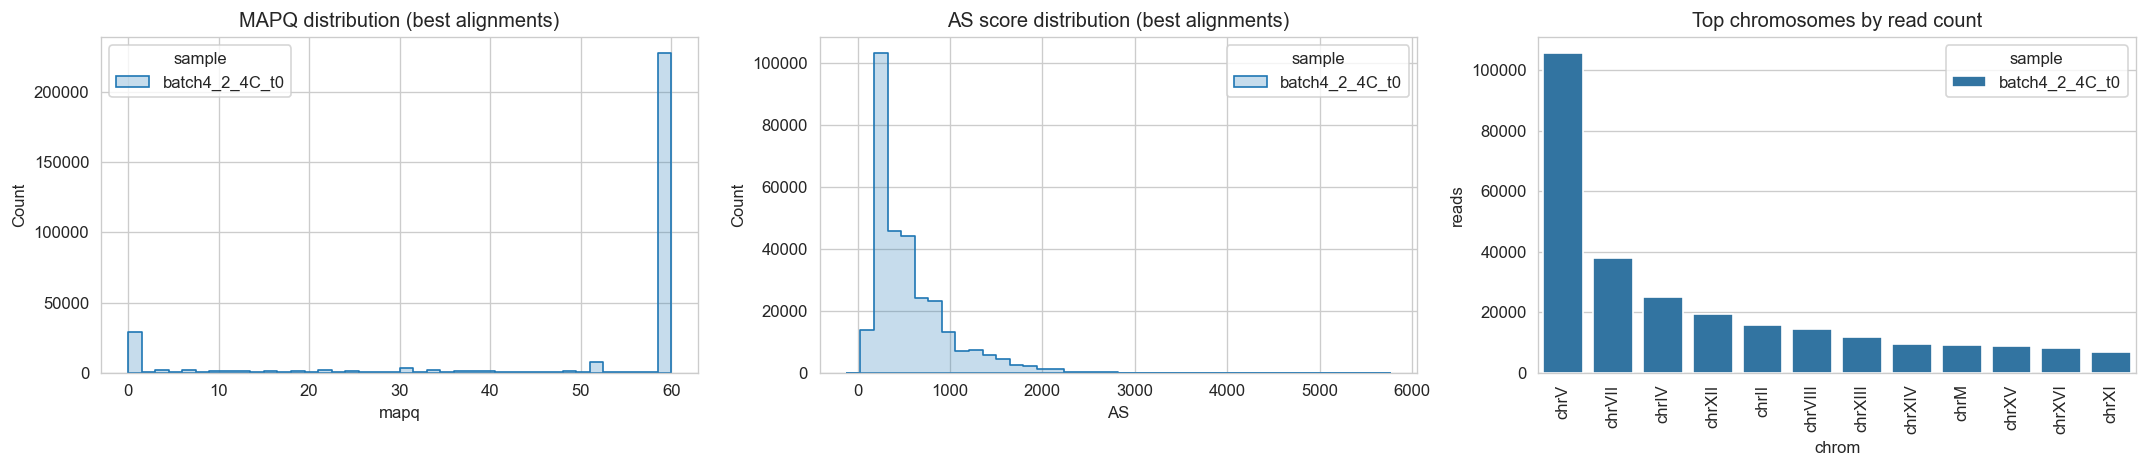

In [8]:
# ---- QC plots ----
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(data=best_alignments, x='mapq', hue='sample', bins=40, element='step', stat='count', common_norm=False, ax=axes[0])
axes[0].set_title('MAPQ distribution (best alignments)')

sns.histplot(data=best_alignments, x='AS', hue='sample', bins=40, element='step', stat='count', common_norm=False, ax=axes[1])
axes[1].set_title('AS score distribution (best alignments)')

top_chrom = (qc_by_chrom.groupby('sample').head(12)).copy()
sns.barplot(data=top_chrom, x='chrom', y='reads', hue='sample', ax=axes[2])
axes[2].set_title('Top chromosomes by read count')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## Why we bin contacts in 4C

Single-base positions are sparse and noisy in ligation-based assays. Binning into fixed genomic windows (10 kb here) gives a stable estimate of local contact enrichment and enables fair comparisons across chromosomes/samples.

The contact-bin table is the backbone for:
- top-hit ranking,
- chromosome-level interaction maps,
- viewpoint distance analyses, and
- multi-timepoint comparison metrics.


In [10]:
# ---- Build binned contacts ----
df = best_alignments.copy()
df = df[df['chrom'].notna() & (df['chrom'] != '*')].copy()
df['bin_start'] = ((df['pos'] - 1) // BIN_SIZE) * BIN_SIZE + 1
df['bin_end'] = df['bin_start'] + BIN_SIZE - 1
df['bin_id'] = df['chrom'].astype(str) + ':' + df['bin_start'].astype(str) + '-' + df['bin_end'].astype(str)

bin_counts = (
    df.groupby(['sample', 'time_point', 'chrom', 'bin_start', 'bin_end', 'bin_id'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)

bin_counts['freq'] = bin_counts.groupby('sample')['count'].transform(lambda x: x / x.sum())

display(bin_counts.head(15))
print('Unique bins:', bin_counts['bin_id'].nunique())

,sample,time_point,chrom,bin_start,bin_end,bin_id,count,freq
0,batch4_2_4C_t0,0,4C_Viewport,1,10000,4C_Viewport:1-10000,5991,0.019995
1,batch4_2_4C_t0,0,chrI,10001,20000,chrI:10001-20000,9,0.000030
2,batch4_2_4C_t0,0,chrI,30001,40000,chrI:30001-40000,6,0.000020
3,batch4_2_4C_t0,0,chrI,40001,50000,chrI:40001-50000,1,0.000003
4,batch4_2_4C_t0,0,chrI,70001,80000,chrI:70001-80000,63,0.000210
5,batch4_2_4C_t0,0,chrI,80001,90000,chrI:80001-90000,1511,0.005043
6,batch4_2_4C_t0,0,chrI,100001,110000,chrI:100001-110000,25,0.000083
7,batch4_2_4C_t0,0,chrI,120001,130000,chrI:120001-130000,187,0.000624
8,batch4_2_4C_t0,0,chrI,130001,140000,chrI:130001-140000,12,0.000040
9,batch4_2_4C_t0,0,chrI,210001,220000,chrI:210001-220000,25,0.000083


Unique bins: 458


## Interpreting top-hit visualizations with spectral clustering

To align with common contact-map analysis practices in the chromatin literature, the top-hit matrix is treated as a **graph** and analyzed via **spectral clustering**:

1. Build a symmetric affinity matrix among top bins (distance kernel + count similarity).
2. Compute the **normalized Laplacian** $L_{sym} = I - D^{-1/2} A D^{-1/2}$.
3. Use Laplacian eigenvectors for spectral embedding.
4. Select cluster number using a combined eigengap + silhouette criterion.
5. Reorder bins by spectral structure and visualize:
   - affinity heatmap,
   - Laplacian heatmap,
   - covariance map of affinity profiles.

This provides a more principled clustering view than simple sorting while still acknowledging that 4C is primarily viewpoint-to-locus (not direct locus-to-locus) data.


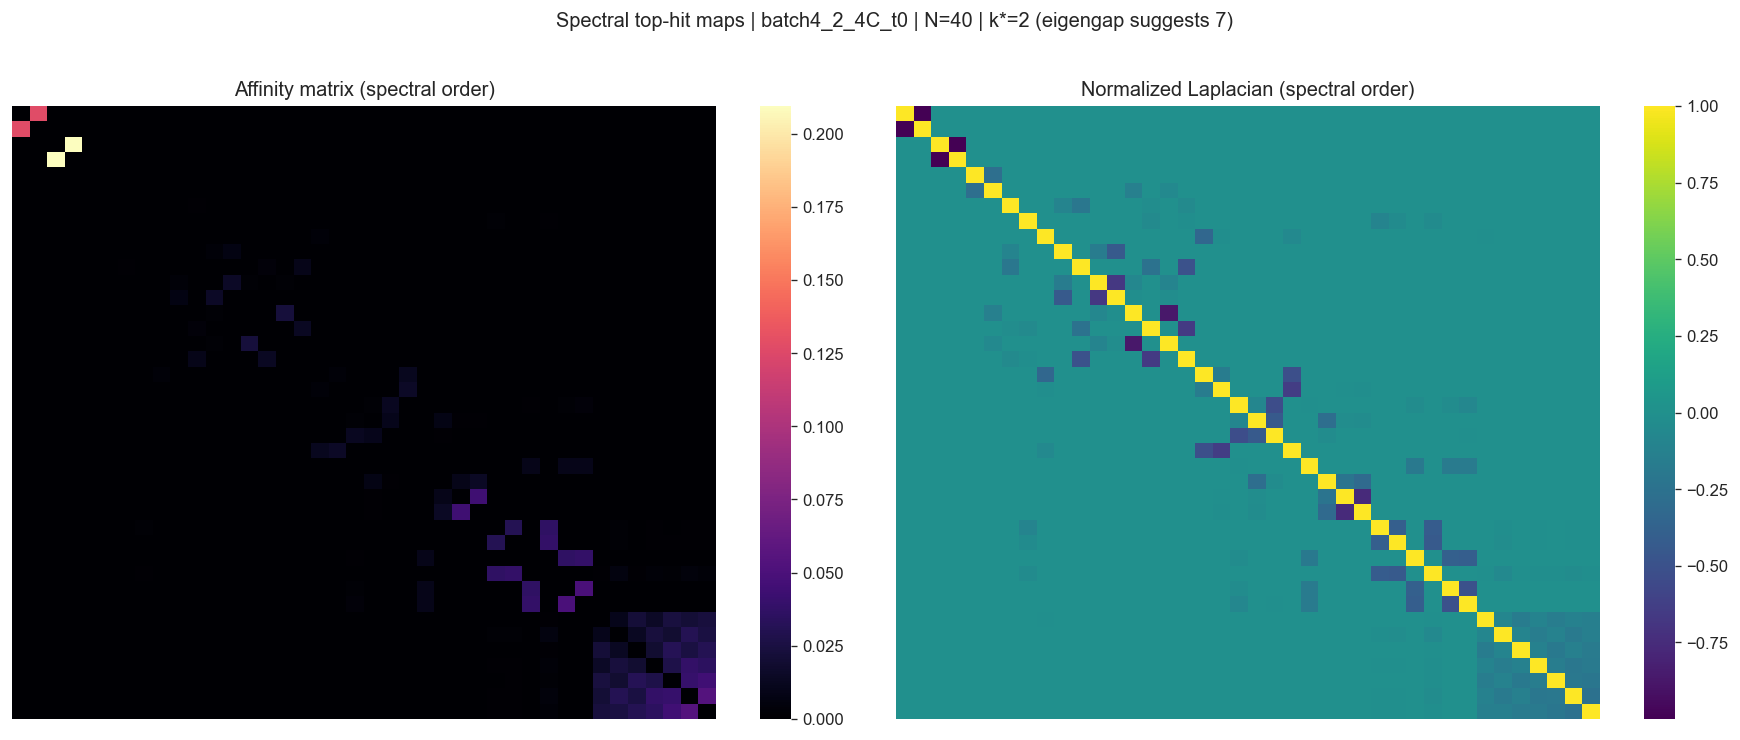

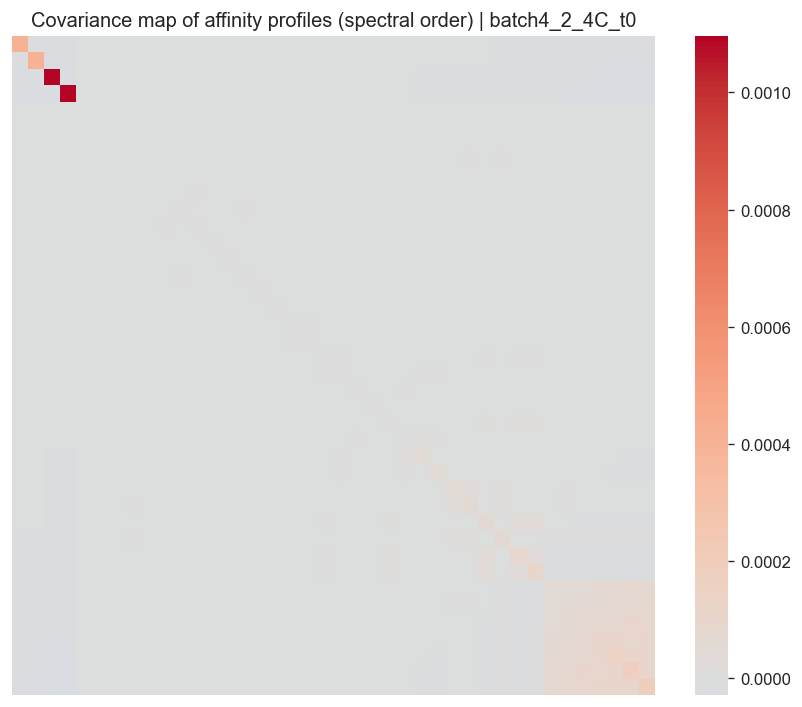

,sample,chrom,bin_start,bin_end,bin_id,count,freq,count_norm,genome_mid,spectral_cluster,fiedler_value,spectral_order
127,batch4_2_4C_t0,chrV,320001,330000,chrV:320001-330000,50385,0.168157,1.000000,3175000.5,0,0.108665,3
118,batch4_2_4C_t0,chrV,110001,120000,chrV:110001-120000,45587,0.152144,0.904773,2965000.5,0,0.108671,4
184,batch4_2_4C_t0,chrVII,830001,840000,chrVII:830001-840000,15119,0.050459,0.300069,4535000.5,1,0.080810,39
115,batch4_2_4C_t0,chrM,70001,80000,chrM:70001-80000,8232,0.027474,0.163382,12055000.5,0,-0.674524,2
0,batch4_2_4C_t0,4C_Viewport,1,10000,4C_Viewport:1-10000,5991,0.019995,0.118904,12065000.5,0,-0.674524,1
202,batch4_2_4C_t0,chrVIII,210001,220000,chrVIII:210001-220000,5343,0.017832,0.106043,5005000.5,1,0.053788,31
15,batch4_2_4C_t0,chrII,110001,120000,chrII:110001-120000,4864,0.016233,0.096537,335000.5,1,0.057998,33
29,batch4_2_4C_t0,chrII,610001,620000,chrII:610001-620000,4683,0.015629,0.092944,835000.5,1,0.026526,20
47,batch4_2_4C_t0,chrIV,90001,100000,chrIV:90001-100000,4301,0.014354,0.085363,1415000.5,1,0.027355,21
64,batch4_2_4C_t0,chrIV,700001,710000,chrIV:700001-710000,4188,0.013977,0.083120,2025000.5,1,0.044678,27


,sample,n_bins,k_optimal,k_eigengap,silhouette_optimal,eigengap_optimal,distance_bandwidth_bp,count_similarity_bandwidth,labels_ordered
0,batch4_2_4C_t0,40,2,7,0.879324,0.000952,150000,0.2,4C_Viewport:1-10000|chrM:70001-80000|chrV:3200...


In [10]:
# ---- Spectral clustering + Laplacian/covariance maps of highest 4C hits ----
p_assoc_heatmap = None
p_laplacian_heatmap = None
p_covariance_map = None
top_hits_heatmap_df = pd.DataFrame()
spectral_model_df = pd.DataFrame()

# Literature-aligned graph view (adapted to 4C one-vs-all context):
# 1) Build bin-bin affinity graph among strongest bins
# 2) Compute normalized graph Laplacian
# 3) Spectral embedding + cluster selection (eigengap + silhouette)
# 4) Reorder matrices by spectral cluster structure and visualize

TOP_HITS_HEATMAP_N = max(30, CONTACT_PLOT_MAX_BARS)
ASSOC_DISTANCE_BANDWIDTH_BP = 150_000
COUNT_SIMILARITY_BANDWIDTH = 0.20
MAX_SPECTRAL_CLUSTERS = 8
RNG_SEED = 42

def _row_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(norms, eps, None)

def _kmeans_np(x: np.ndarray, k: int, n_init: int = 20, max_iter: int = 300, random_state: int = 42):
    rng = np.random.default_rng(random_state)
    n = x.shape[0]
    best = None

    for _ in range(n_init):
        init_idx = rng.choice(n, size=k, replace=False)
        centers = x[init_idx].copy()

        for _ in range(max_iter):
            d2 = ((x[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            labels = np.argmin(d2, axis=1)

            new_centers = centers.copy()
            for j in range(k):
                mask = labels == j
                if np.any(mask):
                    new_centers[j] = x[mask].mean(axis=0)

            if np.allclose(new_centers, centers, rtol=0, atol=1e-8):
                centers = new_centers
                break
            centers = new_centers

        inertia = float(((x - centers[labels]) ** 2).sum())
        if (best is None) or (inertia < best['inertia']):
            best = {'labels': labels.copy(), 'centers': centers.copy(), 'inertia': inertia}

    return best['labels'], best['centers'], best['inertia']

def _silhouette_score_np(x: np.ndarray, labels: np.ndarray) -> float:
    n = x.shape[0]
    uniq = np.unique(labels)
    if len(uniq) < 2 or n < 3:
        return np.nan

    dist = np.sqrt(np.maximum(0.0, ((x[:, None, :] - x[None, :, :]) ** 2).sum(axis=2)))
    sil = np.zeros(n, dtype=float)

    for i in range(n):
        same = labels == labels[i]
        same_count = int(same.sum())

        if same_count <= 1:
            a_i = 0.0
        else:
            a_i = float(dist[i, same].sum() / (same_count - 1))

        b_i = np.inf
        for c in uniq:
            if c == labels[i]:
                continue
            mask = labels == c
            if np.any(mask):
                b_i = min(b_i, float(dist[i, mask].mean()))

        denom = max(a_i, b_i)
        sil[i] = 0.0 if (not np.isfinite(denom) or denom <= 0) else (b_i - a_i) / denom

    return float(np.nanmean(sil))

model_rows = []

for sample_name, sdf in bin_counts.groupby('sample'):
    top = sdf.sort_values('count', ascending=False).head(TOP_HITS_HEATMAP_N).copy()
    if top.empty or len(top) < 6:
        print(f'Skipping spectral maps for {sample_name}: not enough bins.')
        continue

    top['bin_mid'] = 0.5 * (top['bin_start'].astype(float) + top['bin_end'].astype(float))

    observed_chr_len = sdf.groupby('chrom', as_index=False)['bin_end'].max().rename(columns={'bin_end': 'obs_len'})
    if 'YEAST_CHR_LENGTHS' in globals() and isinstance(YEAST_CHR_LENGTHS, dict):
        known_len_df = pd.DataFrame({'chrom': list(YEAST_CHR_LENGTHS.keys()), 'known_len': list(YEAST_CHR_LENGTHS.values())})
        chr_len_df = observed_chr_len.merge(known_len_df, on='chrom', how='outer').fillna(0)
        chr_len_df['chr_len'] = chr_len_df[['obs_len', 'known_len']].max(axis=1).astype(float)
    else:
        chr_len_df = observed_chr_len.copy()
        chr_len_df['chr_len'] = chr_len_df['obs_len'].astype(float)

    order_key = {c: i for i, c in enumerate(CHROM_ORDER)}
    chr_len_df['order_idx'] = chr_len_df['chrom'].map(lambda c: order_key.get(c, 10_000))
    chr_len_df = chr_len_df.sort_values(['order_idx', 'chrom']).reset_index(drop=True)

    offsets = {}
    running = 0.0
    for _, r in chr_len_df.iterrows():
        offsets[str(r['chrom'])] = running
        running += float(r['chr_len'])

    top['genome_mid'] = top.apply(lambda r: float(r['bin_mid']) + float(offsets.get(str(r['chrom']), 0.0)), axis=1)
    top['count_norm'] = top['count'].astype(float) / float(top['count'].max())

    mids = top['genome_mid'].to_numpy(dtype=float)
    cn = top['count_norm'].to_numpy(dtype=float)

    # Affinity design: distance kernel × count similarity × strength term
    dist = np.abs(mids[:, None] - mids[None, :])
    proximity = np.exp(-dist / float(ASSOC_DISTANCE_BANDWIDTH_BP))

    count_delta = np.abs(cn[:, None] - cn[None, :])
    count_similarity = np.exp(-0.5 * (count_delta / float(COUNT_SIMILARITY_BANDWIDTH)) ** 2)

    strength = np.sqrt(np.outer(cn, cn))
    assoc = proximity * count_similarity * strength
    assoc = 0.5 * (assoc + assoc.T)
    np.fill_diagonal(assoc, 0.0)

    # Normalized graph Laplacian: L_sym = I - D^{-1/2} A D^{-1/2}
    degree = assoc.sum(axis=1)
    eps = 1e-12
    d_inv_sqrt = np.diag(1.0 / np.sqrt(np.clip(degree, eps, None)))
    lap_sym = np.eye(len(top), dtype=float) - d_inv_sqrt @ assoc @ d_inv_sqrt

    eigvals, eigvecs = np.linalg.eigh(lap_sym)
    order = np.argsort(eigvals)
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    k_max = min(MAX_SPECTRAL_CLUSTERS, len(top) - 1)
    if k_max < 2:
        print(f'Skipping spectral maps for {sample_name}: k_max < 2.')
        continue

    candidates = list(range(2, k_max + 1))
    score_rows = []

    for k in candidates:
        emb = _row_normalize(eigvecs[:, 1:k+1])
        labels_k, _, inertia_k = _kmeans_np(emb, k=k, n_init=24, max_iter=300, random_state=RNG_SEED)
        sil_k = _silhouette_score_np(emb, labels_k)
        gap_k = float(eigvals[k+1] - eigvals[k]) if (k + 1) < len(eigvals) else float(eigvals[k] - eigvals[k-1])
        score_rows.append({
            'k': int(k),
            'silhouette': sil_k,
            'eigengap': gap_k,
            'inertia': inertia_k,
            'labels': labels_k
        })

    score_df = pd.DataFrame(score_rows)
    sil = score_df['silhouette'].to_numpy(dtype=float)
    gap = score_df['eigengap'].to_numpy(dtype=float)

    sil_norm = np.zeros_like(sil) if np.all(~np.isfinite(sil)) else np.nan_to_num((sil - np.nanmin(sil)) / (np.nanmax(sil) - np.nanmin(sil) + 1e-12), nan=0.0)
    gap_norm = (gap - gap.min()) / (gap.max() - gap.min() + 1e-12)
    score_df['combined_score'] = 0.75 * sil_norm + 0.25 * gap_norm

    best_i = int(score_df['combined_score'].to_numpy().argmax())
    k_opt = int(score_df.loc[best_i, 'k'])
    labels = np.array(score_df.loc[best_i, 'labels'])

    # Eigengap-only suggestion (for reporting)
    k_eigengap = int(score_df.loc[int(score_df['eigengap'].to_numpy().argmax()), 'k'])

    fiedler = eigvecs[:, 1] if eigvecs.shape[1] > 1 else np.zeros(len(top), dtype=float)

    # Reorder: cluster order by median Fiedler value, then within cluster by Fiedler
    cluster_ids = sorted(np.unique(labels), key=lambda c: float(np.median(fiedler[labels == c])))
    ord_idx_parts = []
    for c in cluster_ids:
        idx_c = np.where(labels == c)[0]
        idx_c = idx_c[np.argsort(fiedler[idx_c])]
        ord_idx_parts.append(idx_c)
    ord_idx = np.concatenate(ord_idx_parts)

    assoc_ord = assoc[np.ix_(ord_idx, ord_idx)]
    lap_ord = lap_sym[np.ix_(ord_idx, ord_idx)]
    cov_ord = np.cov(assoc_ord)

    # Attach clustering metadata to per-bin table
    top['spectral_cluster'] = labels
    top['fiedler_value'] = fiedler
    spectral_rank = np.empty(len(top), dtype=int)
    spectral_rank[ord_idx] = np.arange(1, len(top) + 1)
    top['spectral_order'] = spectral_rank

    labels_ordered = top.iloc[ord_idx]['bin_id'].astype(str).tolist()

    # Panel 1: affinity + Laplacian heatmaps (cluster-ordered)
    fig_spec, axes_spec = plt.subplots(1, 2, figsize=(15, 6))
    sns.heatmap(assoc_ord, cmap='magma', xticklabels=False, yticklabels=False, ax=axes_spec[0])
    axes_spec[0].set_title('Affinity matrix (spectral order)')

    sns.heatmap(lap_ord, cmap='viridis', xticklabels=False, yticklabels=False, ax=axes_spec[1])
    axes_spec[1].set_title('Normalized Laplacian (spectral order)')

    fig_spec.suptitle(
        f'Spectral top-hit maps | {sample_name} | N={len(top)} | k*={k_opt} (eigengap suggests {k_eigengap})',
        y=1.02
    )
    plt.tight_layout()
    p_assoc_heatmap = fig_spec
    p_laplacian_heatmap = fig_spec
    plt.show()

    # Panel 2: covariance map over affinity profiles
    plt.figure(figsize=(7, 6))
    ax_cov = sns.heatmap(cov_ord, cmap='coolwarm', center=0, xticklabels=False, yticklabels=False)
    ax_cov.set_title(f'Covariance map of affinity profiles (spectral order) | {sample_name}')
    plt.tight_layout()
    p_covariance_map = plt.gcf()
    plt.show()

    top_hits_heatmap_df = top[[
        'sample', 'chrom', 'bin_start', 'bin_end', 'bin_id',
        'count', 'freq', 'count_norm', 'genome_mid',
        'spectral_cluster', 'fiedler_value', 'spectral_order'
    ]].copy()

    model_rows.append({
        'sample': sample_name,
        'n_bins': int(len(top)),
        'k_optimal': int(k_opt),
        'k_eigengap': int(k_eigengap),
        'silhouette_optimal': float(score_df.loc[best_i, 'silhouette']),
        'eigengap_optimal': float(score_df.loc[best_i, 'eigengap']),
        'distance_bandwidth_bp': int(ASSOC_DISTANCE_BANDWIDTH_BP),
        'count_similarity_bandwidth': float(COUNT_SIMILARITY_BANDWIDTH),
        'labels_ordered': '|'.join(labels_ordered)
    })

if model_rows:
    spectral_model_df = pd.DataFrame(model_rows)

display(top_hits_heatmap_df.head(20))
display(spectral_model_df)

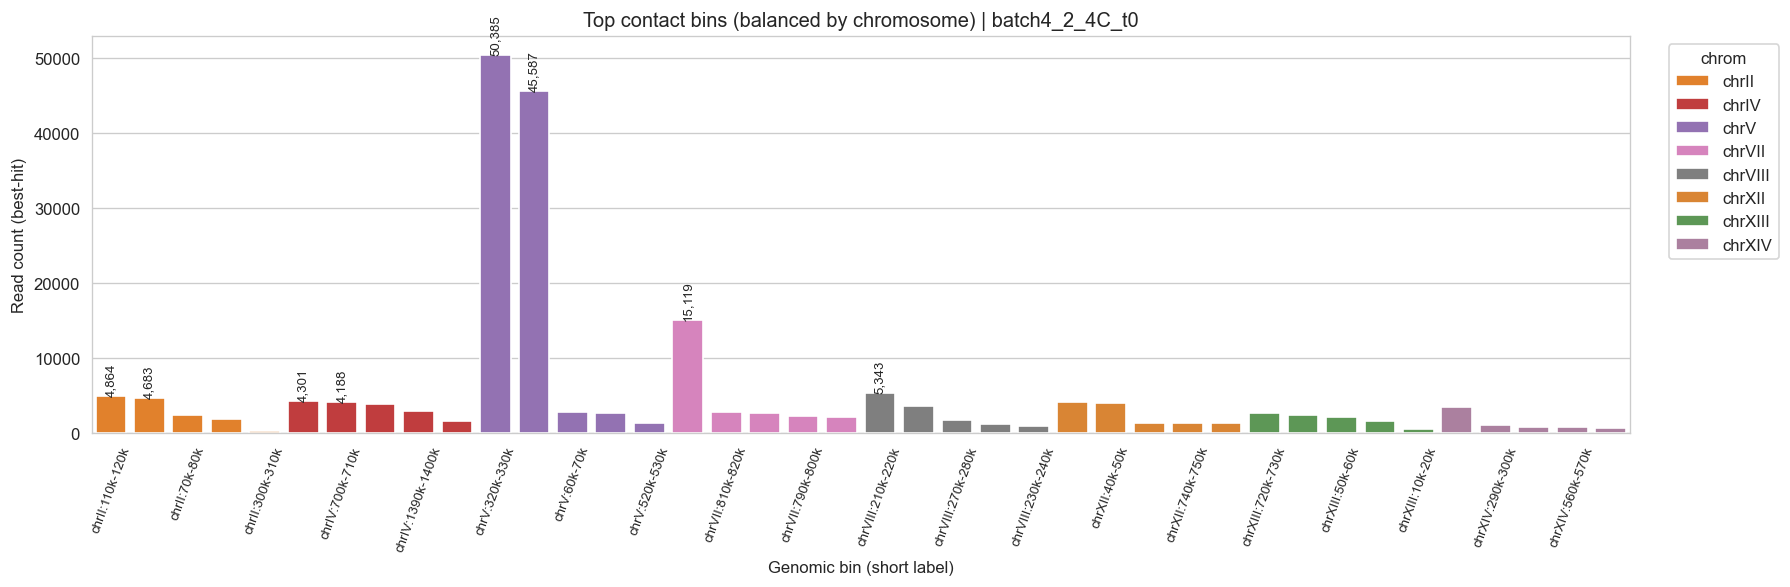

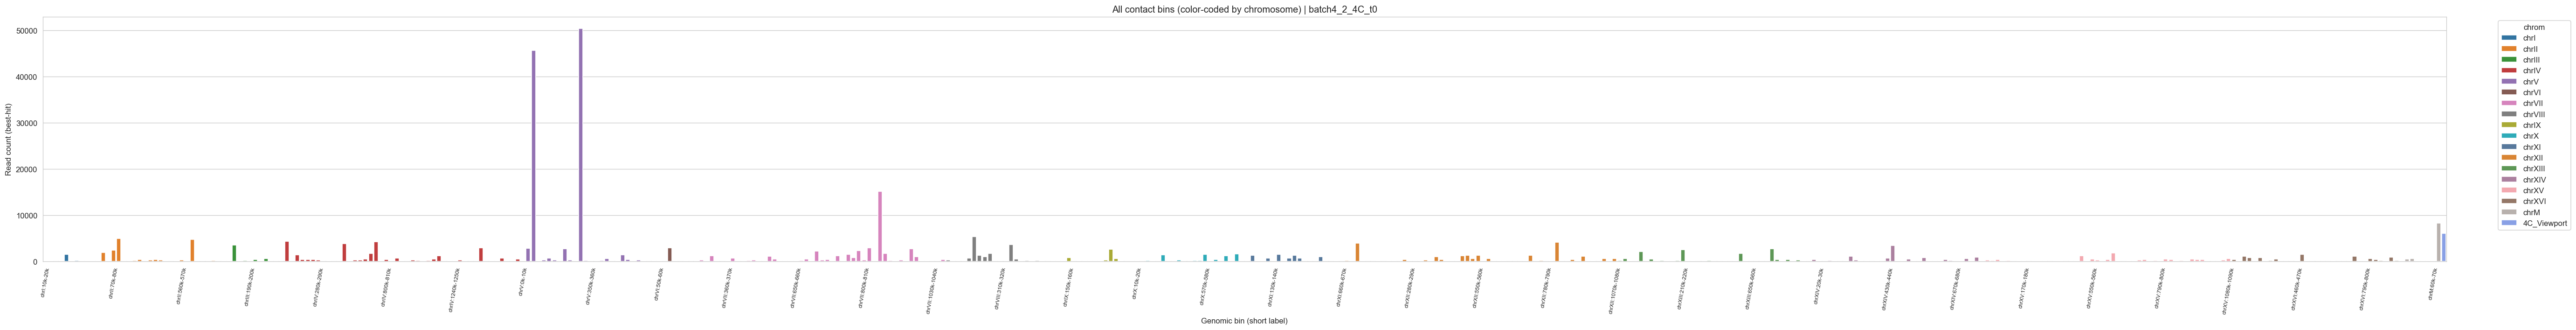

In [15]:
# ---- 4C contact profile plots (readability-polished + all-bin view) ----
p_top_bins = None
p_all_bins = None
top_bins_figs = {}
all_bins_figs = {}

def _short_bin_label(bin_id: str):
    # chrV:320001-330000 -> chrV:320k-330k
    if ':' not in str(bin_id):
        return str(bin_id)
    chrom, span = str(bin_id).split(':', 1)
    if '-' not in span:
        return str(bin_id)
    start_s, end_s = span.split('-', 1)
    try:
        start_k = int(start_s) // 1000
        end_k = int(end_s) // 1000
        return f"{chrom}:{start_k}k-{end_k}k"
    except ValueError:
        return str(bin_id)

chrom_order_index = {c: i for i, c in enumerate(CHROM_ORDER)}
fallback_colors = sns.color_palette('husl', 24).as_hex()

for sample_name, sdf in bin_counts.groupby('sample'):
    # ----------------------------
    # A) Balanced top-bin view
    # ----------------------------
    chrom_rank = (
        sdf.groupby('chrom', as_index=False)['count'].sum()
        .sort_values('count', ascending=False)
        .head(CONTACT_PLOT_TOP_CHROMS)
    )
    chosen_chroms = set(chrom_rank['chrom'].tolist())

    candidate = sdf[sdf['chrom'].isin(chosen_chroms)].copy()
    candidate = candidate.sort_values(['chrom', 'count'], ascending=[True, False])
    per_chrom_top = candidate.groupby('chrom', as_index=False).head(CONTACT_PLOT_BINS_PER_CHROM).copy()

    p = per_chrom_top.sort_values('count', ascending=False).head(CONTACT_PLOT_MAX_BARS).copy()
    p['bin_label_short'] = p['bin_id'].map(_short_bin_label)

    p['chrom_order'] = p['chrom'].map(lambda x: chrom_order_index.get(x, 10_000))
    p = p.sort_values(['chrom_order', 'count'], ascending=[True, False]).reset_index(drop=True)

    hue_order = [c for c in CHROM_ORDER if c in set(p['chrom'])]
    extra_chroms = sorted([c for c in pd.unique(p['chrom']) if c not in set(hue_order)])
    hue_order.extend(extra_chroms)

    palette_map = {}
    for i, chrom in enumerate(hue_order):
        palette_map[chrom] = CHROM_PALETTE.get(chrom, fallback_colors[i % len(fallback_colors)])

    x_order = p['bin_label_short'].tolist()

    plt.figure(figsize=(15, 5))
    ax = sns.barplot(
        data=p,
        x='bin_label_short',
        y='count',
        hue='chrom',
        order=x_order,
        hue_order=hue_order,
        dodge=False,
        palette=palette_map
    )
    ax.set_title(f'Top contact bins (balanced by chromosome) | {sample_name}')
    ax.set_xlabel('Genomic bin (short label)')
    ax.set_ylabel('Read count (best-hit)')

    n_labels = len(p)
    step = max(1, n_labels // 16)
    for i, tick in enumerate(ax.get_xticklabels()):
        tick.set_rotation(70)
        tick.set_fontsize(8)
        tick.set_visible(i % step == 0)

    top_n_annot = min(8, len(p))
    top_rows = p.sort_values('count', ascending=False).head(top_n_annot)
    x_lookup = {lab: idx for idx, lab in enumerate(x_order)}
    for _, row in top_rows.iterrows():
        x_idx = x_lookup.get(row['bin_label_short'])
        if x_idx is not None:
            ax.text(
                x_idx,
                row['count'],
                f"{int(row['count']):,}",
                ha='center',
                va='bottom',
                fontsize=8,
                rotation=90
            )

    plt.legend(title='chrom', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    p_top_bins = plt.gcf()
    top_bins_figs[sample_name] = p_top_bins
    plt.show()

    # ----------------------------
    # B) Full all-bin color-coded view
    # ----------------------------
    p_all = sdf.copy()
    p_all['chrom_order'] = p_all['chrom'].map(lambda x: chrom_order_index.get(x, 10_000))
    p_all = p_all.sort_values(['chrom_order', 'chrom', 'bin_start'], ascending=[True, True, True]).reset_index(drop=True)
    p_all['bin_label_short'] = p_all['bin_id'].map(_short_bin_label)

    hue_order_all = [c for c in CHROM_ORDER if c in set(p_all['chrom'])]
    extra_chroms_all = sorted([c for c in pd.unique(p_all['chrom']) if c not in set(hue_order_all)])
    hue_order_all.extend(extra_chroms_all)

    palette_map_all = {}
    for i, chrom in enumerate(hue_order_all):
        palette_map_all[chrom] = CHROM_PALETTE.get(chrom, fallback_colors[i % len(fallback_colors)])

    x_order_all = p_all['bin_label_short'].tolist()

    fig_w = max(18, min(46, 0.16 * len(p_all)))
    plt.figure(figsize=(fig_w, 6))
    ax_all = sns.barplot(
        data=p_all,
        x='bin_label_short',
        y='count',
        hue='chrom',
        order=x_order_all,
        hue_order=hue_order_all,
        dodge=False,
        palette=palette_map_all
    )
    ax_all.set_title(f'All contact bins (color-coded by chromosome) | {sample_name}')
    ax_all.set_xlabel('Genomic bin (short label)')
    ax_all.set_ylabel('Read count (best-hit)')

    n_labels_all = len(p_all)
    step_all = max(1, n_labels_all // 35)
    for i, tick in enumerate(ax_all.get_xticklabels()):
        tick.set_rotation(80)
        tick.set_fontsize(7)
        tick.set_visible(i % step_all == 0)

    plt.legend(title='chrom', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    p_all_bins = plt.gcf()
    all_bins_figs[sample_name] = p_all_bins
    plt.show()

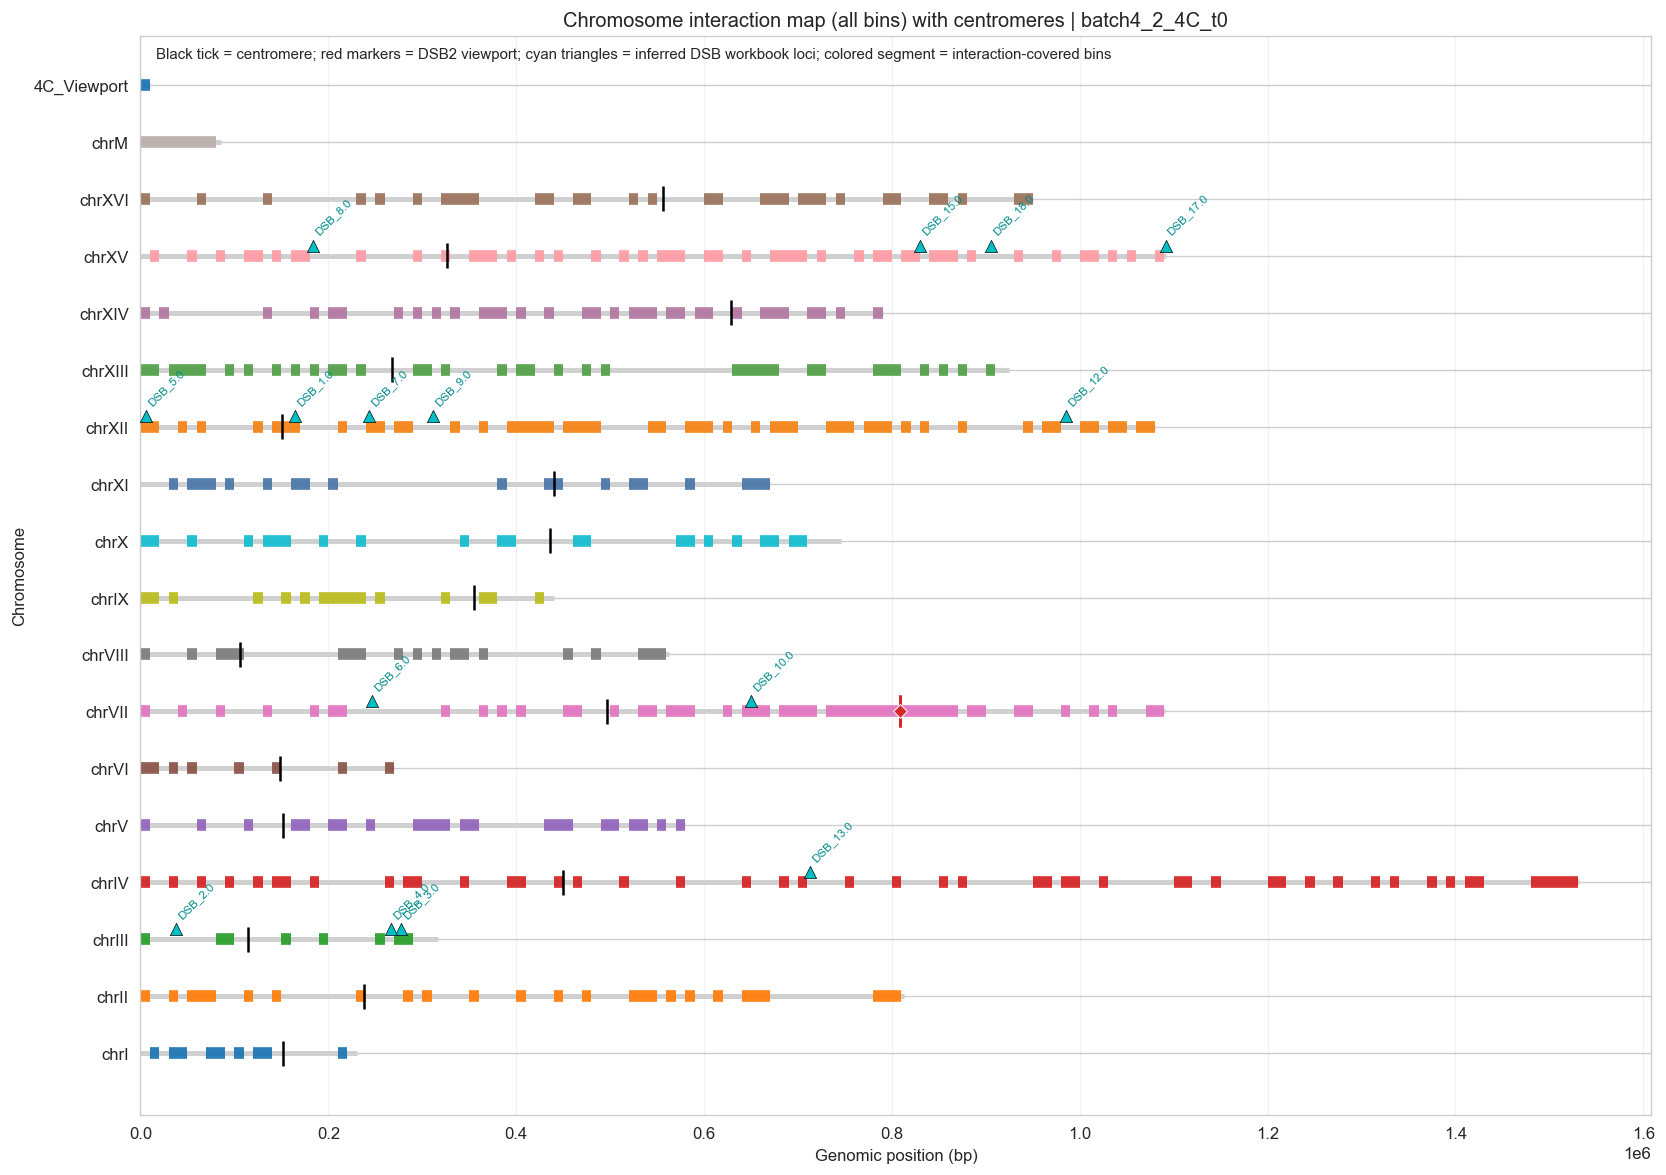

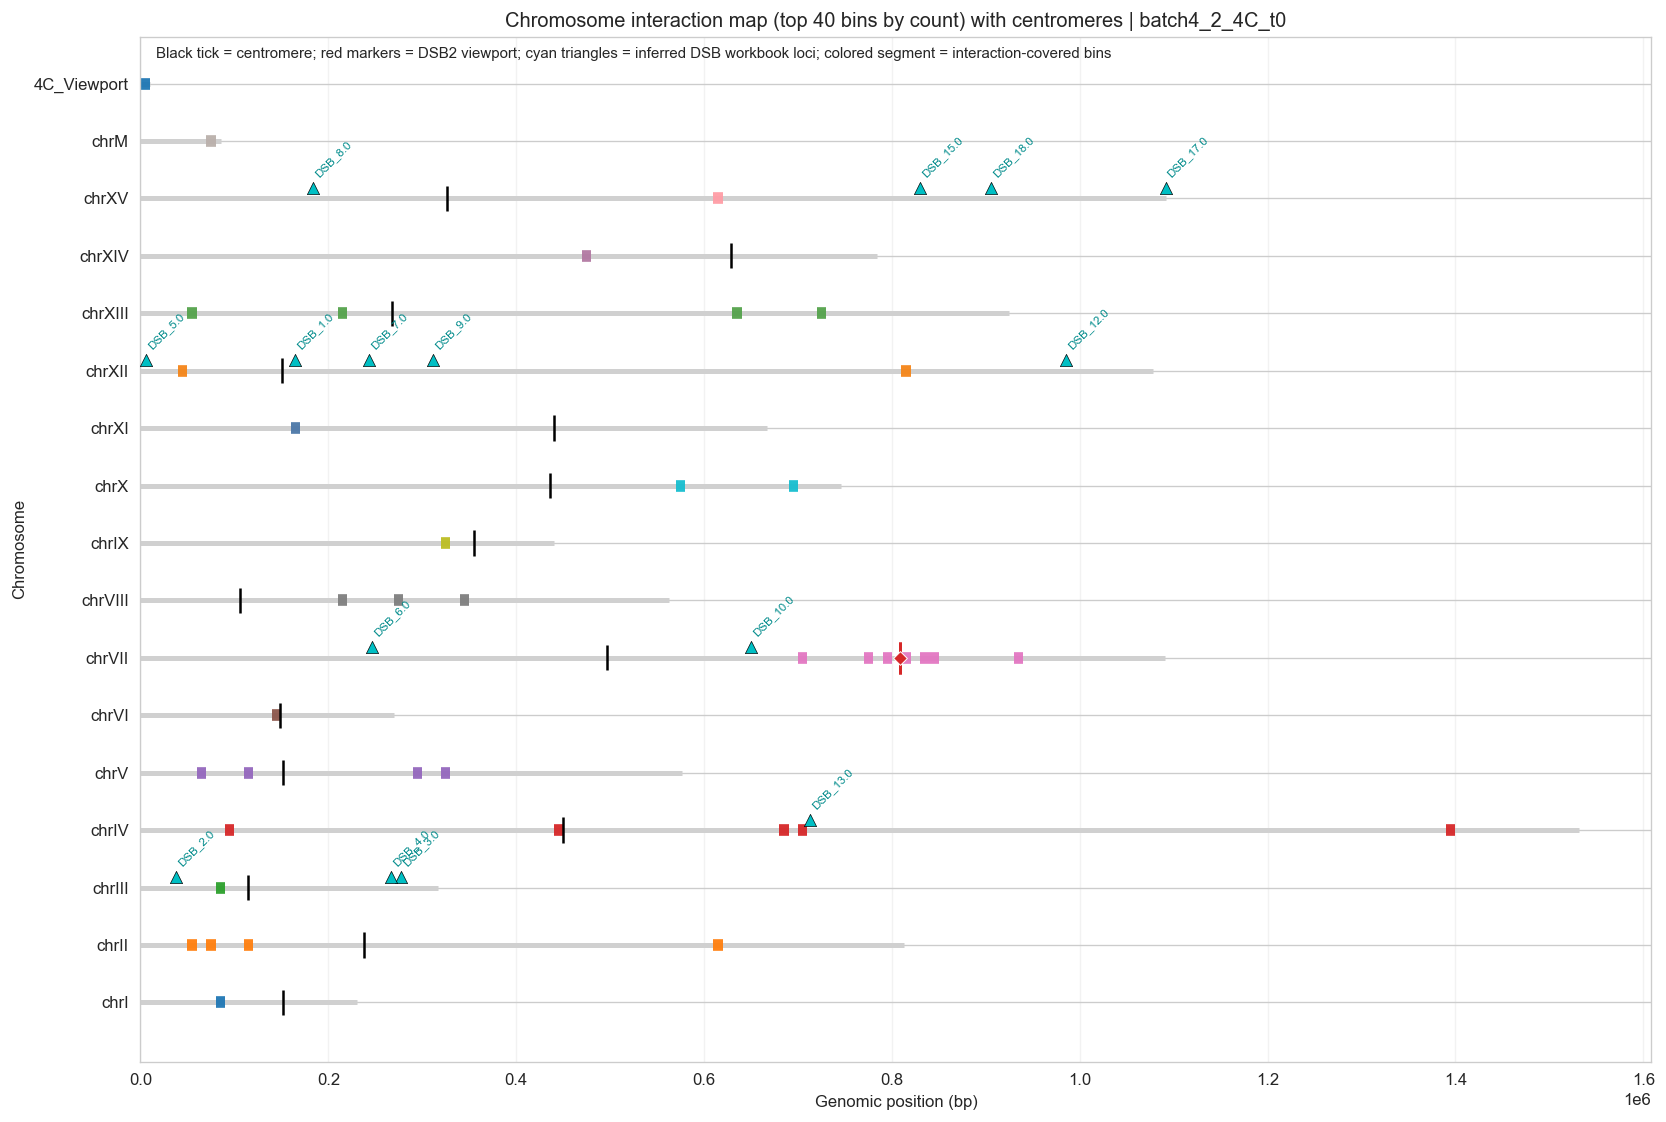

In [11]:
# ---- Chromosome interaction maps: full + top-hit bins ----
p_chr_map = None
chr_map_figs = {}
p_chr_map_tophits = None
chr_map_tophits_figs = {}

# Number of highest-count bins to retain in the top-hit map (per sample)
CHR_MAP_TOP_HITS_N = max(40, CONTACT_PLOT_MAX_BARS)

# sacCer3 chromosome lengths (bp) and centromere positions (approx, bp)
YEAST_CHR_LENGTHS = {
    'chrI': 230218, 'chrII': 813184, 'chrIII': 316620, 'chrIV': 1531933,
    'chrV': 576874, 'chrVI': 270161, 'chrVII': 1090940, 'chrVIII': 562643,
    'chrIX': 439888, 'chrX': 745751, 'chrXI': 666816, 'chrXII': 1078177,
    'chrXIII': 924431, 'chrXIV': 784333, 'chrXV': 1091291, 'chrXVI': 948066,
    'chrM': 85779
}

YEAST_CENTROMERES = {
    'chrI': 151583, 'chrII': 238323, 'chrIII': 114385, 'chrIV': 449711,
    'chrV': 151465, 'chrVI': 148510, 'chrVII': 497038, 'chrVIII': 105703,
    'chrIX': 355629, 'chrX': 436425, 'chrXI': 440246, 'chrXII': 150947,
    'chrXIII': 268031, 'chrXIV': 628758, 'chrXV': 326584, 'chrXVI': 556070
}

def _merge_adjacent_intervals(df_chr: pd.DataFrame):
    """Merge overlapping/adjacent bins into interaction spans."""
    if df_chr.empty:
        return []
    d = df_chr.sort_values(['bin_start', 'bin_end']).reset_index(drop=True)
    merged = []

    cur_start = int(d.loc[0, 'bin_start'])
    cur_end = int(d.loc[0, 'bin_end'])

    for _, row in d.iloc[1:].iterrows():
        s = int(row['bin_start'])
        e = int(row['bin_end'])
        if s <= cur_end + 1:
            cur_end = max(cur_end, e)
        else:
            merged.append((cur_start, cur_end))
            cur_start, cur_end = s, e

    merged.append((cur_start, cur_end))
    return merged

def _plot_chromosome_map(sdf_in: pd.DataFrame, sample_name: str, title_suffix: str):
    present = [c for c in CHROM_ORDER if c in set(sdf_in['chrom'])]
    extra = sorted([c for c in pd.unique(sdf_in['chrom']) if c not in set(present)])
    chroms_plot = present + extra

    if not chroms_plot:
        return None

    dsb_loc_use = pd.DataFrame()
    if 'dsb_locations' in globals() and isinstance(dsb_locations, pd.DataFrame) and not dsb_locations.empty:
        dsb_loc_use = dsb_locations.copy()
        dsb_loc_use = dsb_loc_use[dsb_loc_use['chrom'].notna() & dsb_loc_use['position'].notna()].copy()
        if not dsb_loc_use.empty:
            dsb_loc_use['chrom'] = dsb_loc_use['chrom'].astype(str)
            dsb_loc_use['position'] = pd.to_numeric(dsb_loc_use['position'], errors='coerce')
            dsb_loc_use = dsb_loc_use[dsb_loc_use['position'].notna()].copy()

    dsb2 = DSB2_VIEWPORT if 'DSB2_VIEWPORT' in globals() else None
    dsb2_chrom = str(dsb2.get('chrom')) if isinstance(dsb2, dict) and dsb2.get('chrom') is not None else None
    dsb2_start = int(dsb2.get('start')) if isinstance(dsb2, dict) and dsb2.get('start') is not None else None
    dsb2_end = int(dsb2.get('end')) if isinstance(dsb2, dict) and dsb2.get('end') is not None else None

    fig_h = max(6, 0.45 * len(chroms_plot) + 1.8)
    plt.figure(figsize=(14, fig_h))
    ax = plt.gca()

    for idx, chrom in enumerate(chroms_plot, start=1):
        y = idx
        cdf = sdf_in[sdf_in['chrom'] == chrom].copy()

        observed_end = int(cdf['bin_end'].max()) if not cdf.empty else 1
        chr_len = int(max(YEAST_CHR_LENGTHS.get(chrom, 1), observed_end))

        # Chromosome baseline
        ax.hlines(y, 1, chr_len, color='#d0d0d0', linewidth=3, zorder=1)

        # Centromere marker
        cen = YEAST_CENTROMERES.get(chrom)
        if cen is not None and 1 <= cen <= chr_len:
            ax.vlines(cen, y - 0.22, y + 0.22, color='black', linewidth=1.5, zorder=3)

        # Interaction spans (merged from occupied bins)
        spans = _merge_adjacent_intervals(cdf[['bin_start', 'bin_end']]) if not cdf.empty else []
        color = CHROM_PALETTE.get(chrom, '#1f77b4')
        for s, e in spans:
            ax.hlines(y, s, e, color=color, linewidth=7, alpha=0.95, zorder=2)

        # DSB2 / 4C viewport marker on the matching chromosome
        # NOTE: interval can be tiny at genome-wide x-scale, so draw segment + boundaries + midpoint marker.
        if (dsb2_chrom is not None) and (chrom == dsb2_chrom) and (dsb2_start is not None) and (dsb2_end is not None):
            dsb2_s = max(1, min(dsb2_start, chr_len))
            dsb2_e = max(1, min(dsb2_end, chr_len))
            if dsb2_e < dsb2_s:
                dsb2_s, dsb2_e = dsb2_e, dsb2_s
            dsb2_mid = 0.5 * (dsb2_s + dsb2_e)

            ax.hlines(y, dsb2_s, dsb2_e, color='#d62728', linewidth=10, zorder=5)
            ax.vlines([dsb2_s, dsb2_e], y - 0.28, y + 0.28, color='#d62728', linewidth=1.8, zorder=6)
            ax.scatter([dsb2_mid], [y], color='#d62728', s=34, marker='D', edgecolors='white', linewidths=0.6, zorder=7)

        # Additional DSB locations inferred from workbook sequences (distinct color)
        if not dsb_loc_use.empty:
            dsub = dsb_loc_use[dsb_loc_use['chrom'] == chrom].copy()
            if not dsub.empty:
                xs = dsub['position'].astype(float).clip(lower=1, upper=chr_len)
                ys = np.repeat(y + 0.18, len(dsub))
                ax.scatter(xs, ys, color='#00BFC4', s=54, marker='^', edgecolors='black', linewidths=0.4, zorder=8)
                for _, rr in dsub.iterrows():
                    px = float(max(1, min(chr_len, rr['position'])))
                    label_txt = str(rr.get('dsb_name', 'DSB'))
                    ax.text(px, y + 0.34, label_txt, fontsize=7, rotation=45, ha='left', va='bottom', color='#008B8B', zorder=9)

    ax.set_yticks(range(1, len(chroms_plot) + 1))
    ax.set_yticklabels(chroms_plot)
    ax.set_xlabel('Genomic position (bp)')
    ax.set_ylabel('Chromosome')
    ax.set_title(f'Chromosome interaction map ({title_suffix}) with centromeres | {sample_name}')
    ax.grid(axis='x', alpha=0.25)
    ax.set_xlim(left=0)

    ax.text(
        0.01, 0.99,
        'Black tick = centromere; red markers = DSB2 viewport; cyan triangles = inferred DSB workbook loci; colored segment = interaction-covered bins',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9
    )

    plt.tight_layout()
    return plt.gcf()

for sample_name, sdf in bin_counts.groupby('sample'):
    # Full interaction coverage map
    p_chr_map = _plot_chromosome_map(sdf, sample_name, 'all bins')
    if p_chr_map is not None:
        chr_map_figs[sample_name] = p_chr_map
        plt.show()

    # Top-hit-only map (highest-count bins only)
    sdf_top = sdf.sort_values('count', ascending=False).head(CHR_MAP_TOP_HITS_N).copy()
    p_chr_map_tophits = _plot_chromosome_map(
        sdf_top,
        sample_name,
        f'top {CHR_MAP_TOP_HITS_N} bins by count'
    )
    if p_chr_map_tophits is not None:
        chr_map_tophits_figs[sample_name] = p_chr_map_tophits
        plt.show()

## Why chromosome maps include centromeres and DSB2 markers

Genome-scale maps are most interpretable when structural landmarks are visible.

- **Centromeres** provide positional context for chromosome architecture.  
- **DSB2 viewport markers** indicate the biological anchor used for this 4C experiment.  
- **Top-hit-only maps** highlight strongest candidate interaction regions without full-bin clutter.

Together, these plots help distinguish broad background coverage from biologically interesting focal contacts.


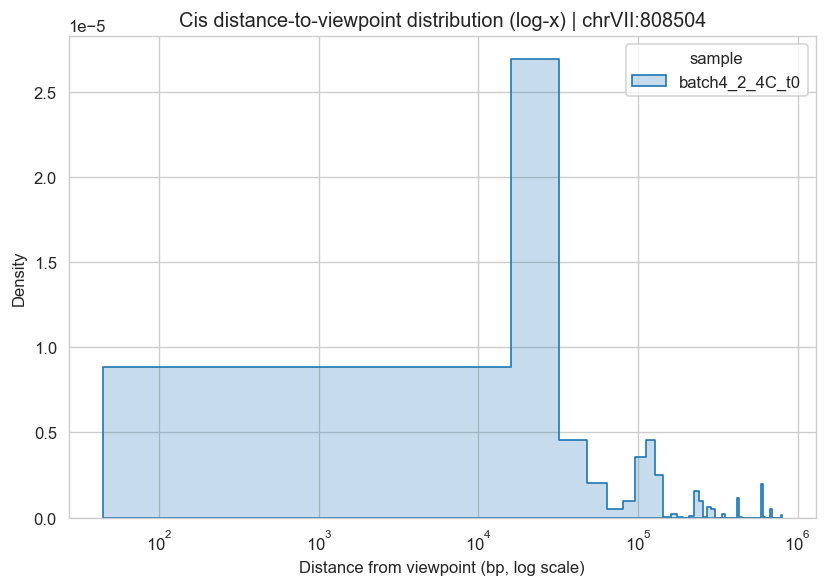

In [17]:
# ---- Viewpoint-aware distance decay (optional) ----
p_decay = None

if VIEWPOINT.get('chrom') is not None and VIEWPOINT.get('position') is not None:
    vchr = str(VIEWPOINT['chrom'])
    vpos = int(VIEWPOINT['position'])

    dfd = best_alignments.copy()
    dfd['is_cis_to_viewpoint'] = dfd['chrom'].astype(str).eq(vchr)
    dfd['distance_bp'] = np.where(
        dfd['is_cis_to_viewpoint'],
        np.abs(dfd['pos'].astype(float) - vpos),
        np.nan
    )

    dfd_cis = dfd[dfd['is_cis_to_viewpoint'] & dfd['distance_bp'].notna() & (dfd['distance_bp'] > 0)].copy()

    if len(dfd_cis) >= 10:
        plt.figure(figsize=(7, 5))
        sns.histplot(data=dfd_cis, x='distance_bp', hue='sample', bins=50, element='step', stat='density', common_norm=False)
        plt.xscale('log')
        plt.title(f'Cis distance-to-viewpoint distribution (log-x) | {vchr}:{vpos}')
        plt.xlabel('Distance from viewpoint (bp, log scale)')
        plt.ylabel('Density')
        plt.tight_layout()
        p_decay = plt.gcf()
        plt.show()
else:
    print('Viewpoint not set; skipping viewpoint-distance analyses.')

## Why viewpoint-distance decay is biologically informative

A hallmark of chromosome conformation data is that contact probability generally decreases with genomic distance in cis.

This section evaluates that expected decay from the configured DSB2 viewpoint, which helps:
- sanity-check that signal follows plausible chromatin behavior, and
- flag datasets where technical artifacts dominate over biological structure.


In [18]:
# ---- Advanced multi-sample comparisons (runs only if 2+ samples) ----
p_ma = None
p_corr = None

available_timepoints = sorted([tp for tp in pd.unique(bin_counts['time_point']) if pd.notna(tp)])

if len(available_timepoints) >= 2:
    t0 = int(min(available_timepoints))
    t1 = int(max(available_timepoints))

    wide = (
        bin_counts[bin_counts['time_point'].isin([t0, t1])]
        .groupby(['bin_id', 'time_point'], as_index=False)['count'].sum()
        .pivot(index='bin_id', columns='time_point', values='count')
        .fillna(0)
        .reset_index()
    )

    if t0 in wide.columns and t1 in wide.columns and len(wide) > 0:
        eps = 1e-6
        wide['A'] = 0.5 * np.log10((wide[t0] + eps) * (wide[t1] + eps))
        wide['M'] = np.log2((wide[t1] + eps) / (wide[t0] + eps))

        plt.figure(figsize=(7, 5))
        sns.scatterplot(data=wide, x='A', y='M', s=20, alpha=0.65)
        plt.axhline(0, ls='--', c='gray', lw=1)
        plt.title(f'4C MA plot: t{t1} vs t{t0}')
        plt.xlabel('A = mean abundance (log10)')
        plt.ylabel('M = log2 fold-change')
        plt.tight_layout()
        p_ma = plt.gcf()
        plt.show()

        # Correlation t0 vs t1
        x = wide[t0].to_numpy(dtype=float)
        y = wide[t1].to_numpy(dtype=float)
        valid = np.isfinite(x) & np.isfinite(y)
        r = np.corrcoef(x[valid], y[valid])[0, 1] if valid.sum() >= 2 else np.nan

        plt.figure(figsize=(6, 6))
        sns.scatterplot(x=x + 1e-6, y=y + 1e-6, s=18, alpha=0.65)
        lim = max((x + 1e-6).max(), (y + 1e-6).max())
        plt.plot([1e-6, lim], [1e-6, lim], ls='--', c='gray')
        plt.xscale('log')
        plt.yscale('log')
        plt.title(f'4C bin count correlation: t{t1} vs t{t0} (r={r:.3f})')
        plt.xlabel(f'Count at t{t0} (log)')
        plt.ylabel(f'Count at t{t1} (log)')
        plt.tight_layout()
        p_corr = plt.gcf()
        plt.show()
else:
    print('Single-timepoint dataset detected; fold-change/correlation sections skipped.')

Single-timepoint dataset detected; fold-change/correlation sections skipped.


## Reproducible reporting outputs

All major tables and figures are exported so the biological conclusions can be reviewed outside the notebook and compared across reruns, filter settings, or future batches.

This is especially important for 4C experiments where interpretation often requires side-by-side QC, contact profiles, and region-level follow-up.


In [19]:
# ---- Save outputs ----
best_alignments.to_csv(OUT_DIR / 'best_alignments_per_read.csv', index=False)
qc_metrics.to_csv(OUT_DIR / 'qc_metrics_summary.csv', index=False)
qc_by_chrom.to_csv(OUT_DIR / 'qc_by_chromosome.csv', index=False)
bin_counts.to_csv(OUT_DIR / 'binned_contact_counts.csv', index=False)

# Save motif attribution tables if available
if 'motif_filter_summary' in globals() and motif_filter_summary is not None and not motif_filter_summary.empty:
    motif_filter_summary.to_csv(OUT_DIR / 'motif_filter_summary.csv', index=False)
if 'motif_filter_totals' in globals() and motif_filter_totals is not None and not motif_filter_totals.empty:
    motif_filter_totals.to_csv(OUT_DIR / 'motif_filter_totals.csv', index=False)

# Save spectral heatmap tables/figures if available
if 'top_hits_heatmap_df' in globals() and top_hits_heatmap_df is not None and not top_hits_heatmap_df.empty:
    top_hits_heatmap_df.to_csv(OUT_DIR / 'top_hits_heatmap_bins.csv', index=False)
if 'spectral_model_df' in globals() and spectral_model_df is not None and not spectral_model_df.empty:
    spectral_model_df.to_csv(OUT_DIR / 'top_hits_spectral_model_summary.csv', index=False)
if 'p_assoc_heatmap' in globals() and p_assoc_heatmap is not None:
    p_assoc_heatmap.savefig(OUT_DIR / 'top_hits_association_heatmap_clustered.png', bbox_inches='tight')
if 'p_laplacian_heatmap' in globals() and p_laplacian_heatmap is not None:
    p_laplacian_heatmap.savefig(OUT_DIR / 'top_hits_laplacian_heatmap_spectral.png', bbox_inches='tight')
if 'p_covariance_map' in globals() and p_covariance_map is not None:
    p_covariance_map.savefig(OUT_DIR / 'top_hits_covariance_map_spectral.png', bbox_inches='tight')

# Save latest generated figures if available
if 'fig' in globals() and fig is not None:
    fig.savefig(OUT_DIR / 'qc_distributions.png', bbox_inches='tight')

# Save balanced top-bin figure(s)
if 'top_bins_figs' in globals() and isinstance(top_bins_figs, dict) and len(top_bins_figs) > 0:
    for sname, fobj in top_bins_figs.items():
        if fobj is not None:
            fobj.savefig(OUT_DIR / f'top_contact_bins_balanced__{sname}.png', bbox_inches='tight')
if p_top_bins is not None:
    p_top_bins.savefig(OUT_DIR / 'top_contact_bins_balanced.png', bbox_inches='tight')

# Save all-bin color-coded figure(s)
if 'all_bins_figs' in globals() and isinstance(all_bins_figs, dict) and len(all_bins_figs) > 0:
    for sname, fobj in all_bins_figs.items():
        if fobj is not None:
            fobj.savefig(OUT_DIR / f'all_contact_bins_color_coded__{sname}.png', bbox_inches='tight')
if 'p_all_bins' in globals() and p_all_bins is not None:
    p_all_bins.savefig(OUT_DIR / 'all_contact_bins_color_coded.png', bbox_inches='tight')

# Save chromosome interaction map figure(s)
if 'chr_map_figs' in globals() and isinstance(chr_map_figs, dict) and len(chr_map_figs) > 0:
    for sname, fobj in chr_map_figs.items():
        if fobj is not None:
            fobj.savefig(OUT_DIR / f'chromosome_interaction_map__{sname}.png', bbox_inches='tight')
if 'p_chr_map' in globals() and p_chr_map is not None:
    p_chr_map.savefig(OUT_DIR / 'chromosome_interaction_map.png', bbox_inches='tight')

# Save top-hit chromosome interaction map figure(s)
if 'chr_map_tophits_figs' in globals() and isinstance(chr_map_tophits_figs, dict) and len(chr_map_tophits_figs) > 0:
    for sname, fobj in chr_map_tophits_figs.items():
        if fobj is not None:
            fobj.savefig(OUT_DIR / f'chromosome_interaction_map_tophits__{sname}.png', bbox_inches='tight')
if 'p_chr_map_tophits' in globals() and p_chr_map_tophits is not None:
    p_chr_map_tophits.savefig(OUT_DIR / 'chromosome_interaction_map_tophits.png', bbox_inches='tight')

# Save optional figures
if p_decay is not None:
    p_decay.savefig(OUT_DIR / 'viewpoint_distance_decay.png', bbox_inches='tight')
if p_ma is not None:
    p_ma.savefig(OUT_DIR / '4C_MA_plot.png', bbox_inches='tight')
if p_corr is not None:
    p_corr.savefig(OUT_DIR / '4C_timepoint_correlation.png', bbox_inches='tight')

# Save inferred DSB locations (from workbook sequence lookup)
if 'dsb_locations' in globals() and isinstance(dsb_locations, pd.DataFrame) and not dsb_locations.empty:
    dsb_locations.to_csv(OUT_DIR / 'dsb_locations_saccer3_approx.csv', index=False)

print(f'Saved outputs to: {OUT_DIR}')
sorted([p.name for p in OUT_DIR.iterdir()])

Saved outputs to: c:\Users\dunnmk\wilsontew-data-analysis\Outputs\4C_python


['all_contact_bins_color_coded.png',
 'all_contact_bins_color_coded__batch4_2_4C_t0.png',
 'best_alignments_per_read.csv',
 'binned_contact_counts.csv',
 'chromosome_interaction_map.png',
 'chromosome_interaction_map__batch4_2_4C_t0.png',
 'chromosome_interaction_map_tophits.png',
 'chromosome_interaction_map_tophits__batch4_2_4C_t0.png',
 'dsb_locations_saccer3_approx.csv',
 'motif_filter_summary.csv',
 'motif_filter_totals.csv',
 'qc_by_chromosome.csv',
 'qc_distributions.png',
 'qc_metrics_summary.csv',
 'top_contact_bins_balanced.png',
 'top_contact_bins_balanced__batch4_2_4C_t0.png',
 'top_hits_association_heatmap_clustered.png',
 'top_hits_covariance_map_spectral.png',
 'top_hits_heatmap_bins.csv',
 'top_hits_laplacian_heatmap_spectral.png',
 'top_hits_spectral_model_summary.csv',
 'viewpoint_distance_decay.png']

## Selected 4C-seq references (for interpretation)

- Simonis M. *et al.* (2006) **Nuclear organization of active and inactive chromatin domains uncovered by chromosome conformation capture-on-chip (4C)**. *Nature Genetics*.
- van de Werken HJG. *et al.* (2012) **4C technology: protocols and data analysis**. *Methods in Enzymology*.
- de Wit E, de Laat W. (2012) **A decade of 3C technologies: insights into nuclear organization**. *Genes & Development*.
- Sati S, Cavalli G. (2017) **Chromosome conformation capture technologies and their impact in understanding genome function**. *Genome Biology*.

These references support the biological assumptions used above: viewpoint-centric contact inference, distance-dependent decay in cis, and the importance of stringent mapping/filtering before biological interpretation.
